# PRCP-1002: Handwritten Digits Recognition

## Problem Statement
Classify images of handwritten digits into one of 10 classes representing
integers 0 to 9, using the MNIST dataset.

## Objective
1. Prepare a complete data analysis report on the given data.
2. Classify a given image of a handwritten digit into one of the 10 classes.
3. Compare various models and find the classifier that works better.

## Dataset
MNIST — 70,000 grayscale images of handwritten digits, each 28×28 pixels,
split into 60,000 training and 10,000 test samples. Input features are the
images; the output is one of 10 classes (digits 0–9).

## Approach
Load and validate the data, explore it, preprocess it through one shared
pipeline, then train and compare KNN, SVM and a neural network under identical
evaluation. Select a best model, test it on a real handwritten image, and
document the challenges that came up along the way.

## 1. Setup and Data Loading


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print("Everything imported successfully!")
print("TensorFlow:", tf.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Everything imported successfully!
TensorFlow: 2.21.0
Matplotlib: 3.11.1


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [3]:
# =========================================================
# DATA ACQUISITION AND VALIDATION
# =========================================================
# The MNIST dataset is loaded using the Keras dataset loader.
# Basic properties such as shape, data type, pixel range,
# class labels, missing values, and class counts are checked
# before preprocessing and model development.

import numpy as np
from tensorflow.keras.datasets import mnist

# 1. # Load the MNIST training and test sets.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Basic shape checks
print("--- Shapes ---")
print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}")
print(f"y_test:  {y_test.shape}")

# 3. Data types
print("\n--- Data types ---")
print(f"x_train dtype: {x_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")

# 4. Pixel value range (confirms whether normalization is needed)
print("\n--- Pixel value range ---")
print(f"x_train min: {x_train.min()}, max: {x_train.max()}")
print(f"x_test  min: {x_test.min()}, max: {x_test.max()}")

# 5. Label / class check
print("\n--- Label check ---")
train_classes = np.unique(y_train)
test_classes = np.unique(y_test)
print(f"Unique classes in y_train: {train_classes}")
print(f"Unique classes in y_test:  {test_classes}")
print(f"Number of classes (train): {len(train_classes)}")
print(f"Number of classes (test):  {len(test_classes)}")

# 6. Missing/invalid data check
print("\n--- Missing/invalid data check ---")
print(f"NaNs in x_train: {np.isnan(x_train).sum()}")
print(f"NaNs in x_test:  {np.isnan(x_test).sum()}")

# 7. Class distribution (raw counts — visualized properly in EDA stage)
print("\n--- Class distribution (train) ---")
for cls in train_classes:
    count = np.sum(y_train == cls)
    print(f"  Digit {cls}: {count} samples")


--- Shapes ---
x_train: (60000, 28, 28)
y_train: (60000,)
x_test:  (10000, 28, 28)
y_test:  (10000,)

--- Data types ---
x_train dtype: uint8
y_train dtype: uint8

--- Pixel value range ---
x_train min: 0, max: 255
x_test  min: 0, max: 255

--- Label check ---
Unique classes in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique classes in y_test:  [0 1 2 3 4 5 6 7 8 9]
Number of classes (train): 10
Number of classes (test):  10

--- Missing/invalid data check ---
NaNs in x_train: 0
NaNs in x_test:  0

--- Class distribution (train) ---
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


## 2. Exploratory Data Analysis

In [4]:

# =========================================================
# STAGE: EDA — Setup
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plot styling across the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Reproducibility for any random sampling in this notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("EDA environment ready.")

EDA environment ready.


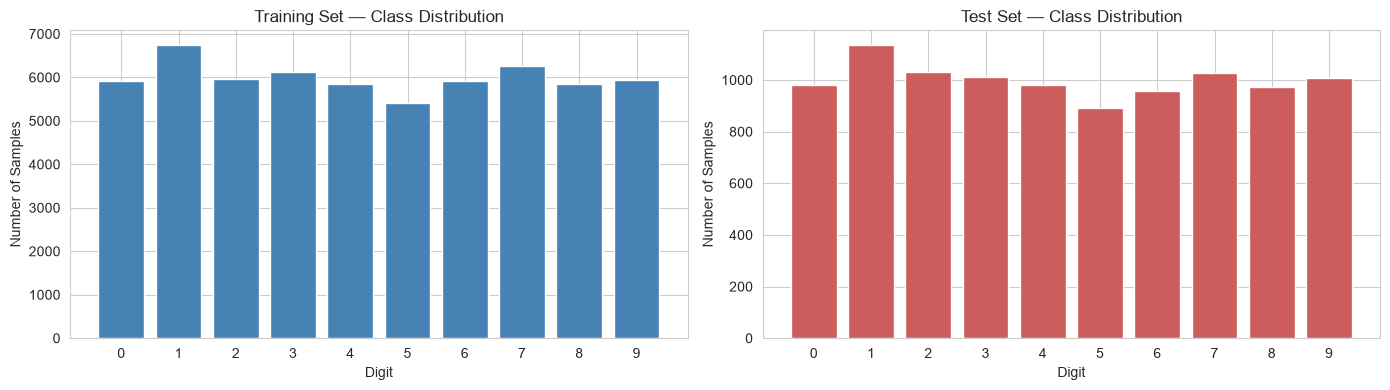

Train — most frequent digit:  1 (6742 samples)
Train — least frequent digit: 5 (5421 samples)
Imbalance ratio (max/min): 1.24


In [5]:
# =========================================================
# EDA 1: Class distribution (train vs test)
# =========================================================

classes, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(classes, train_counts, color="steelblue")
axes[0].set_title("Training Set — Class Distribution")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xticks(classes)

axes[1].bar(classes, test_counts, color="indianred")
axes[1].set_title("Test Set — Class Distribution")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Number of Samples")
axes[1].set_xticks(classes)

plt.tight_layout()
plt.show()

# Quantify the imbalance rather than eyeballing it
imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Train — most frequent digit:  {classes[train_counts.argmax()]} ({train_counts.max()} samples)")
print(f"Train — least frequent digit: {classes[train_counts.argmin()]} ({train_counts.min()} samples)")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

**Interpretation:**

Both training and test sets contain all 10 digit classes with a fairly even spread.
Digit 1 is the most common (6,742 samples) and digit 5 the least common (5,421 samples),
giving an imbalance ratio of 1.24:1.

This is only a mild imbalance, so **overall accuracy remains a valid primary metric**.
However, because the classes are not perfectly balanced, we will also report
**macro-averaged precision, recall and F1-score**, which weight every digit equally.
This prevents a model that performs poorly on an under-represented digit (such as 5)
from hiding behind a strong overall accuracy score.

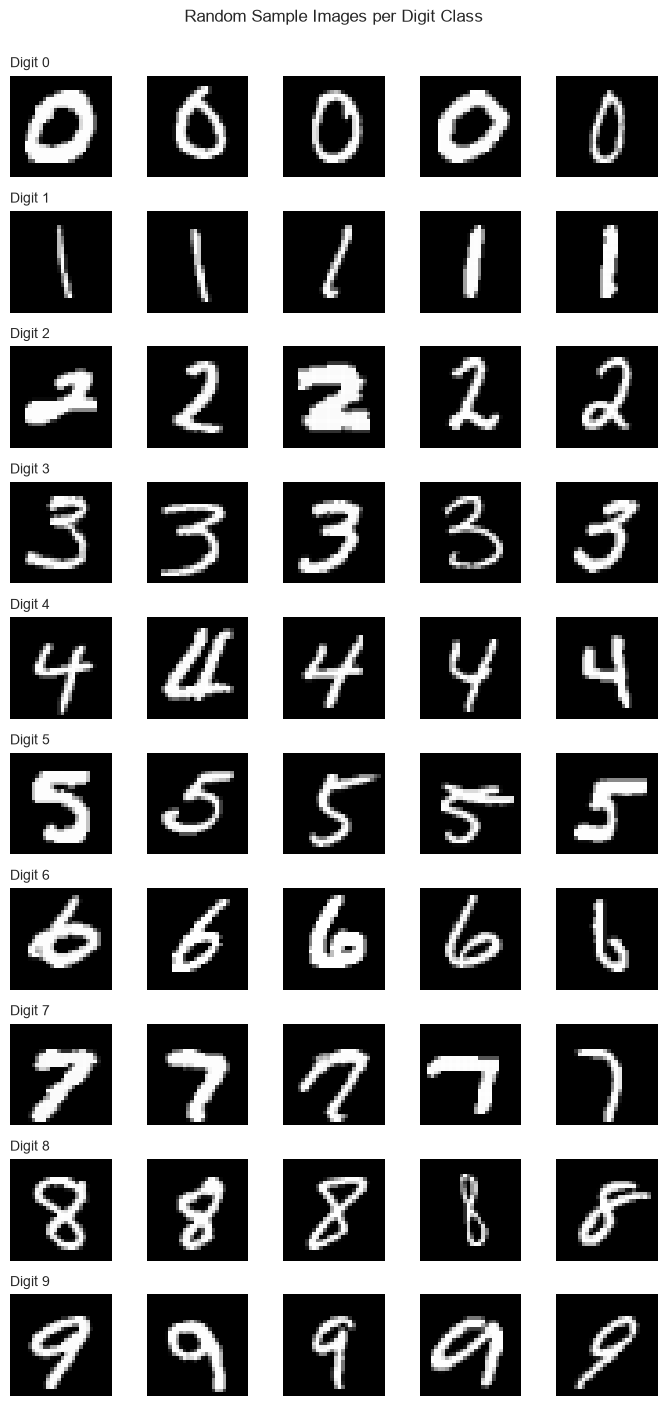

In [6]:
# =========================================================
# EDA 2: Representative images — 5 random samples per digit
# =========================================================

SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(10, SAMPLES_PER_CLASS, figsize=(7, 14))

for digit in range(10):
    # # Random samples showing within-class variation
    idxs = np.where(y_train == digit)[0]
    chosen = np.random.choice(idxs, SAMPLES_PER_CLASS, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[digit, col]
        ax.imshow(x_train[idx], cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"Digit {digit}", loc="left", fontsize=10)

plt.suptitle("Random Sample Images per Digit Class", y=1.001)
plt.tight_layout()
plt.show()

**Interpretation:**

Each row displays five randomly selected images for one digit class, and every image
visually matches its assigned label. This confirms **label integrity**, the images and
labels are correctly paired.

The rows also reveal substantial **within-class variation** in handwriting style:
differences in stroke thickness, slant, size and how each digit is formed.

This variation is the core difficulty of the task. It means a good classifier cannot
rely on exact pixel matching; it must learn features that generalise across many
different handwriting styles.

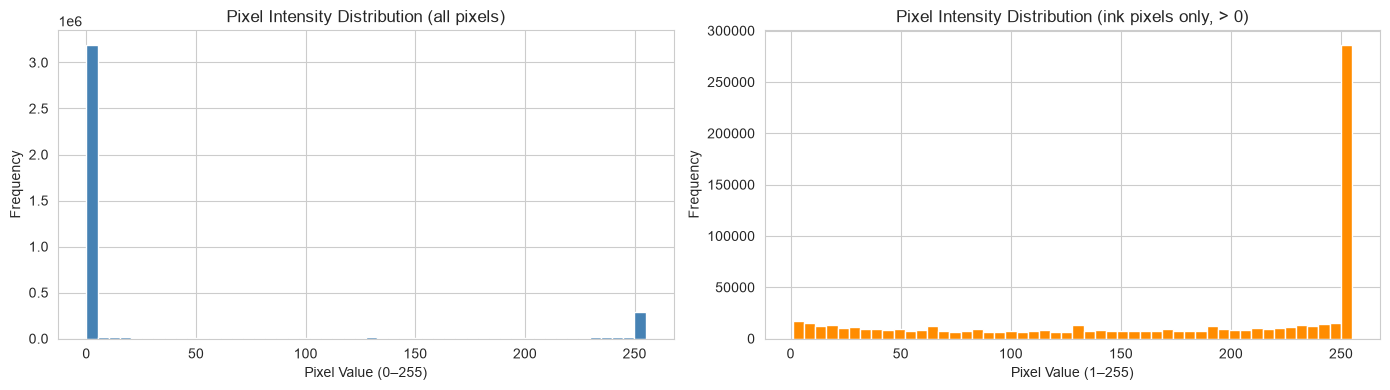

Fraction of pixels that are pure background (value 0): 80.97%
Mean pixel value (all):       33.12
Mean pixel value (ink only):  174.02


In [7]:
# =========================================================
# EDA 3: Pixel intensity distribution
# =========================================================

# Sample a subset of images for the histogram — 60,000 x 784 pixels is
# ~47M values, which is slow to plot and adds no extra insight.
sample_idx = np.random.choice(len(x_train), 5000, replace=False)
pixel_values = x_train[sample_idx].ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution — dominated by background
axes[0].hist(pixel_values, bins=50, color="steelblue")
axes[0].set_title("Pixel Intensity Distribution (all pixels)")
axes[0].set_xlabel("Pixel Value (0–255)")
axes[0].set_ylabel("Frequency")

# Non-zero pixels only — shows how the actual ink is distributed
axes[1].hist(pixel_values[pixel_values > 0], bins=50, color="darkorange")
axes[1].set_title("Pixel Intensity Distribution (ink pixels only, > 0)")
axes[1].set_xlabel("Pixel Value (1–255)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Quantify how sparse the images are
zero_fraction = (pixel_values == 0).mean()
print(f"Fraction of pixels that are pure background (value 0): {zero_fraction:.2%}")
print(f"Mean pixel value (all):       {pixel_values.mean():.2f}")
print(f"Mean pixel value (ink only):  {pixel_values[pixel_values > 0].mean():.2f}")

**Interpretation:**

Pixel values range from 0 to 255, confirming that **normalisation is required** before
training. Models such as SVM and neural networks are sensitive to input scale, so we
will rescale all pixels to the range [0, 1].

The distribution is highly sparse: **80.97% of all pixels are pure background (value 0)**,
which is why the overall mean pixel value is low at 33.12. When background pixels are
excluded, the mean rises sharply to 174.02; showing that where ink is present, it is
generally written boldly toward the bright end of the scale rather than in faint grey tones.

Two practical takeaways:
1. Most of each image carries no information, so the effective signal is concentrated
   in a small central region of the 28×28 grid.
2. The strong separation between background (0) and ink (~174 average) means the digits
   have good contrast, which is favourable for classification.

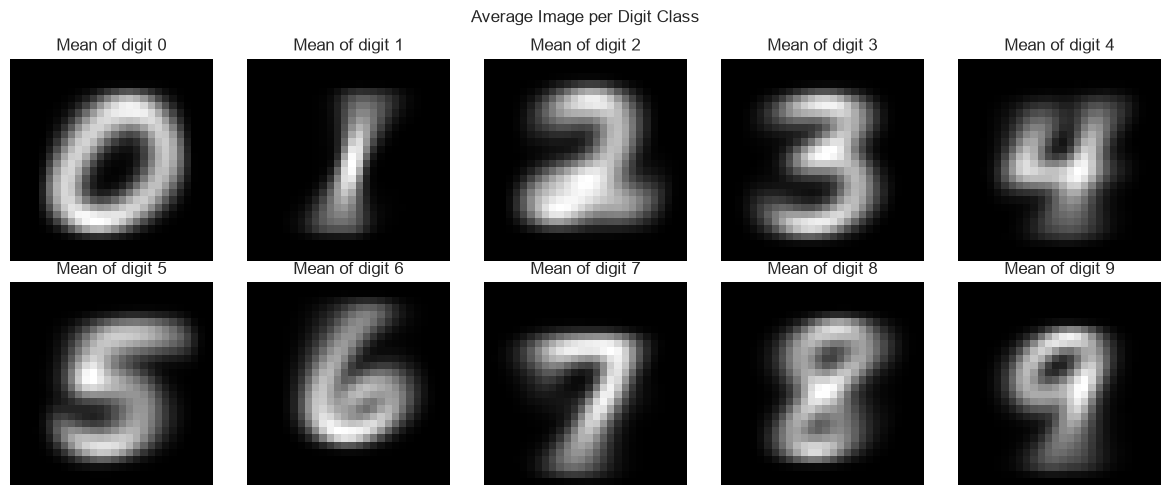

In [8]:
# =========================================================
# EDA 4: Mean image per digit class
# =========================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit in range(10):
    mean_img = x_train[y_train == digit].mean(axis=0)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(mean_img, cmap="gray")
    ax.set_title(f"Mean of digit {digit}")
    ax.axis("off")

plt.suptitle("Average Image per Digit Class")
plt.tight_layout()
plt.show()

**Interpretation:**

Averaging all training images for each digit produces a blurred "prototype" of that digit.
Sharper averages (such as 0 and 1) indicate that people write those digits consistently.
Blurrier averages indicate greater variation in writing style.

More importantly, several prototypes share overlapping ink regions, notably the pairs
**4 and 9**, **3 and 8**, and **5 and 3**. Digits that occupy similar pixel space are
harder to separate.

This gives us an **advance hypothesis to test**: if our models make errors, they are most
likely to occur between these visually similar pairs. We will check this directly against
the confusion matrices in the Model Evaluation stage rather than assuming it holds.

## 3. Data Preprocessing

In [9]:
# =========================================================
# STAGE: DATA PREPROCESSING
# Purpose: Normalise, flatten, and create a validation split.
# One shared pipeline so all models are compared fairly.
# =========================================================

from sklearn.model_selection import train_test_split

# --- 1. Normalise pixel values from [0, 255] to [0, 1] ---
# Cast to float32 (not float64) to halve memory usage — important because
# 60,000 x 784 float64 values would consume ~376 MB unnecessarily.
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("--- After normalisation ---")
print(f"x_train_norm range: {x_train_norm.min()} to {x_train_norm.max()}")
print(f"x_train_norm dtype: {x_train_norm.dtype}")

# --- 2. Flatten each 28x28 image into a 784-feature vector ---
IMG_HEIGHT, IMG_WIDTH = x_train.shape[1], x_train.shape[2]
N_FEATURES = IMG_HEIGHT * IMG_WIDTH   # derived, not hard-coded

x_train_flat = x_train_norm.reshape(-1, N_FEATURES)
x_test_flat  = x_test_norm.reshape(-1, N_FEATURES)

print("\n--- After flattening ---")
print(f"x_train_flat: {x_train_flat.shape}")
print(f"x_test_flat:  {x_test_flat.shape}")
print(f"Features per image: {N_FEATURES}")

# --- 3. Carve a validation set out of the training data ---
# Stratified so the validation set keeps the same class proportions.
# The official 10,000-image test set stays untouched until final evaluation.
X_train, X_val, y_train_split, y_val = train_test_split(
    x_train_flat,
    y_train,
    test_size=10000,
    random_state=RANDOM_SEED,
    stratify=y_train
)

# Final naming for the rest of the notebook
X_test = x_test_flat
y_test_final = y_test

print("\n--- Final dataset shapes ---")
print(f"X_train: {X_train.shape}  y_train_split: {y_train_split.shape}")
print(f"X_val:   {X_val.shape}  y_val:         {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test_final:  {y_test_final.shape}")

# --- 4. Validation checks ---
print("\n--- Validation checks ---")
print(f"All values within [0, 1]: {X_train.min() >= 0 and X_train.max() <= 1}")
print(f"No sample leakage (train + val = 60000): "
      f"{X_train.shape[0] + X_val.shape[0] == 60000}")
print(f"Classes present in train: {len(np.unique(y_train_split))}")
print(f"Classes present in val:   {len(np.unique(y_val))}")
print(f"Classes present in test:  {len(np.unique(y_test_final))}")

# Confirm the stratified split preserved class proportions
print("\nClass proportion check (train vs val, should be near-identical):")
for digit in range(10):
    train_pct = (y_train_split == digit).mean() * 100
    val_pct   = (y_val == digit).mean() * 100
    print(f"  Digit {digit}: train {train_pct:.2f}%  |  val {val_pct:.2f}%")

--- After normalisation ---
x_train_norm range: 0.0 to 1.0
x_train_norm dtype: float32

--- After flattening ---
x_train_flat: (60000, 784)
x_test_flat:  (10000, 784)
Features per image: 784

--- Final dataset shapes ---
X_train: (50000, 784)  y_train_split: (50000,)
X_val:   (10000, 784)  y_val:         (10000,)
X_test:  (10000, 784)  y_test_final:  (10000,)

--- Validation checks ---
All values within [0, 1]: True
No sample leakage (train + val = 60000): True
Classes present in train: 10
Classes present in val:   10
Classes present in test:  10

Class proportion check (train vs val, should be near-identical):
  Digit 0: train 9.87%  |  val 9.87%
  Digit 1: train 11.24%  |  val 11.24%
  Digit 2: train 9.93%  |  val 9.93%
  Digit 3: train 10.22%  |  val 10.22%
  Digit 4: train 9.74%  |  val 9.74%
  Digit 5: train 9.04%  |  val 9.03%
  Digit 6: train 9.86%  |  val 9.86%
  Digit 7: train 10.44%  |  val 10.44%
  Digit 8: train 9.75%  |  val 9.75%
  Digit 9: train 9.91%  |  val 9.92%


## 4. Baseline Models and Evaluation Setup

In [10]:
# =========================================================
# STAGE: EVALUATION FRAMEWORK
# Purpose: One shared evaluation function used by EVERY model,
# so the final comparison is fair and consistent.
# =========================================================

import time
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Central store for all model results — populated as we go.
# This becomes the Model Comparison Report later.
model_results = {}


def evaluate_model(name, model, X_eval, y_eval, train_time, predict_on_fit=None):
    """
    Evaluate a trained model using a consistent metric set.

    Parameters
    ----------
    name : str
        Model name, used as the key in model_results.
    model : fitted estimator
        Any model with a .predict() method.
    X_eval, y_eval : arrays
        Evaluation features and true labels.
    train_time : float
        Seconds taken to train the model.
    predict_on_fit : array, optional
        Pre-computed predictions. If None, model.predict() is called.

    Returns
    -------
    dict of computed metrics.
    """
    # Time the prediction step — relevant for production suitability
    start = time.time()
    if predict_on_fit is None:
        y_pred = model.predict(X_eval)
    else:
        y_pred = predict_on_fit
    predict_time = time.time() - start

    # Macro averaging weights every digit equally, so a weak class
    # cannot hide behind strong overall performance.
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision (macro)": precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "F1-Score (macro)": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "Train Time (s)": train_time,
        "Predict Time (s)": predict_time,
    }

    # Store predictions and confusion matrix for later analysis
    model_results[name] = {
        **results,
        "y_pred": y_pred,
        "confusion_matrix": confusion_matrix(y_eval, y_pred),
    }

    # Print a readable summary
    print(f"\n{'='*55}")
    print(f"RESULTS: {name}")
    print(f"{'='*55}")
    print(f"Accuracy:          {results['Accuracy']:.4f}")
    print(f"Precision (macro): {results['Precision (macro)']:.4f}")
    print(f"Recall (macro):    {results['Recall (macro)']:.4f}")
    print(f"F1-Score (macro):  {results['F1-Score (macro)']:.4f}")
    print(f"Train time:        {results['Train Time (s)']:.2f} s")
    print(f"Predict time:      {results['Predict Time (s)']:.2f} s")

    return results


def plot_confusion_matrix(name, class_names=range(10)):
    """Plot the stored confusion matrix for a given model."""
    cm = model_results[name]["confusion_matrix"]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": "Number of samples"})
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted Digit")
    plt.ylabel("True Digit")
    plt.tight_layout()
    plt.show()


print("Evaluation framework ready.")
print("Functions available: evaluate_model(), plot_confusion_matrix()")

Evaluation framework ready.
Functions available: evaluate_model(), plot_confusion_matrix()


In [11]:
# =========================================================
# BASELINE 0: Majority-class guess
# Purpose: Establish the absolute performance floor.
# =========================================================

from sklearn.dummy import DummyClassifier

start = time.time()
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train_split)
dummy_train_time = time.time() - start

evaluate_model("Baseline (Majority Class)", dummy, X_val, y_val, dummy_train_time)

print("\nThis model always predicts the single most common digit.")
print("Any useful model must beat this by a wide margin.")


RESULTS: Baseline (Majority Class)
Accuracy:          0.1124
Precision (macro): 0.0112
Recall (macro):    0.1000
F1-Score (macro):  0.0202
Train time:        0.00 s
Predict time:      0.00 s

This model always predicts the single most common digit.
Any useful model must beat this by a wide margin.


In [48]:
# Simple linear reference point. If KNN/SVM/NN can't clearly beat this,
# they aren't worth the extra compute.
# max_iter raised to 500 — lbfgs hadn't converged at 200 on 784 features.
# n_jobs removed: no longer supported in sklearn 1.8+.

start = time.time()
logreg = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    random_state=RANDOM_SEED
)
logreg.fit(X_train, y_train_split)
logreg_train_time = time.time() - start

evaluate_model("Logistic Regression (Baseline)", logreg, X_val, y_val, logreg_train_time)


RESULTS: Logistic Regression (Baseline)
Accuracy:          0.9227
Precision (macro): 0.9219
Recall (macro):    0.9217
F1-Score (macro):  0.9217
Train time:        17.28 s
Predict time:      0.04 s


{'Model': 'Logistic Regression (Baseline)',
 'Accuracy': 0.9227,
 'Precision (macro)': 0.92188280550975,
 'Recall (macro)': 0.9217246794165714,
 'F1-Score (macro)': 0.9217409508482429,
 'Train Time (s)': 17.276009559631348,
 'Predict Time (s)': 0.03609490394592285}

## 5. Model 1: K-Nearest Neighbors

Tuning k on 10000 train / 2000 val samples...

  k = 1:  accuracy = 0.9470
  k = 3:  accuracy = 0.9460
  k = 5:  accuracy = 0.9345
  k = 7:  accuracy = 0.9325
  k = 9:  accuracy = 0.9305

Best k on subset: 1 (accuracy 0.9470)


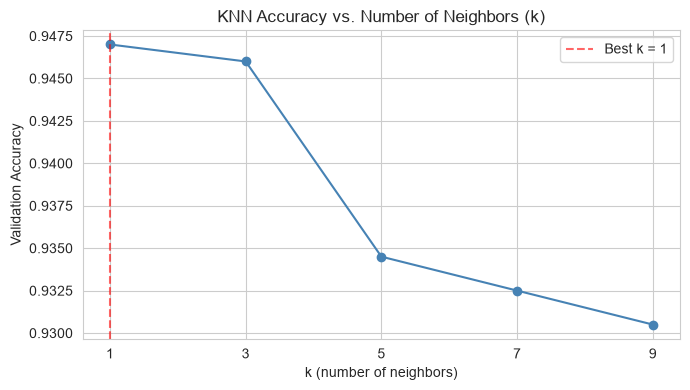

In [13]:
# =========================================================
# MODEL 1: K-Nearest Neighbors — selecting k
# Purpose: Find a good k using a subset, because tuning on the
# full 50,000 training images would be prohibitively slow.
# =========================================================

from sklearn.neighbors import KNeighborsClassifier

# Use a stratified subset for tuning only. The chosen k is then
# applied to the full dataset for the actual model.
TUNE_TRAIN_SIZE = 10000
TUNE_VAL_SIZE = 2000

X_tune_train = X_train[:TUNE_TRAIN_SIZE]
y_tune_train = y_train_split[:TUNE_TRAIN_SIZE]
X_tune_val = X_val[:TUNE_VAL_SIZE]
y_tune_val = y_val[:TUNE_VAL_SIZE]

k_values = [1, 3, 5, 7, 9]
k_scores = []

print(f"Tuning k on {TUNE_TRAIN_SIZE} train / {TUNE_VAL_SIZE} val samples...\n")

for k in k_values:
    knn_tune = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_tune.fit(X_tune_train, y_tune_train)
    score = knn_tune.score(X_tune_val, y_tune_val)
    k_scores.append(score)
    print(f"  k = {k}:  accuracy = {score:.4f}")

BEST_K = k_values[int(np.argmax(k_scores))]
print(f"\nBest k on subset: {BEST_K} (accuracy {max(k_scores):.4f})")

# Visualise how accuracy varies with k
plt.figure(figsize=(7, 4))
plt.plot(k_values, k_scores, marker="o", color="steelblue")
plt.axvline(BEST_K, color="red", linestyle="--", alpha=0.6, label=f"Best k = {BEST_K}")
plt.title("KNN Accuracy vs. Number of Neighbors (k)")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# =========================================================
# MODEL 1: KNN — runtime probe
# Purpose: Measure actual prediction speed on a small sample
# and extrapolate, so we know the real cost before running full.
# =========================================================

# Training KNN is just storing the data — this is genuinely fast
start = time.time()
knn = KNeighborsClassifier(n_neighbors=BEST_K, n_jobs=-1)
knn.fit(X_train, y_train_split)
knn_train_time = time.time() - start
print(f"KNN training time (full 50,000 images): {knn_train_time:.2f} s")

# Probe prediction speed on a small sample
PROBE_SIZE = 500
start = time.time()
_ = knn.predict(X_val[:PROBE_SIZE])
probe_time = time.time() - start

per_sample = probe_time / PROBE_SIZE
estimated_full = per_sample * len(X_val)

print(f"\nPrediction probe on {PROBE_SIZE} samples: {probe_time:.2f} s")
print(f"Per-sample cost: {per_sample*1000:.2f} ms")
print(f"ESTIMATED time for all {len(X_val)} validation images: "
      f"{estimated_full:.1f} s  (~{estimated_full/60:.1f} minutes)")

KNN training time (full 50,000 images): 0.06 s

Prediction probe on 500 samples: 0.38 s
Per-sample cost: 0.76 ms
ESTIMATED time for all 10000 validation images: 7.6 s  (~0.1 minutes)


In [15]:
# =========================================================
# MODEL 1: K-Nearest Neighbors — final model
# =========================================================
# Note on k: the subset tuning showed k=1 (0.9470) marginally ahead of
# k=3 (0.9460). That 0.001 gap equals just 2 images out of 2000 — within
# random variation, not a meaningful difference. We select k=3 because it
# uses genuine majority voting among 3 neighbours, making it more robust
# to noisy or atypical training images. k=1 relies on a single nearest
# image with no error correction.

FINAL_K = 3

start = time.time()
knn = KNeighborsClassifier(n_neighbors=FINAL_K, n_jobs=-1)
knn.fit(X_train, y_train_split)
knn_train_time = time.time() - start

print(f"KNN (k={FINAL_K}) trained on {X_train.shape[0]} images "
      f"in {knn_train_time:.2f} s")
print("Predicting on full validation set — expect roughly 40 seconds...\n")

evaluate_model(f"KNN (k={FINAL_K})", knn, X_val, y_val, knn_train_time)

KNN (k=3) trained on 50000 images in 0.02 s
Predicting on full validation set — expect roughly 40 seconds...


RESULTS: KNN (k=3)
Accuracy:          0.9707
Precision (macro): 0.9714
Recall (macro):    0.9703
F1-Score (macro):  0.9707
Train time:        0.02 s
Predict time:      6.56 s


{'Model': 'KNN (k=3)',
 'Accuracy': 0.9707,
 'Precision (macro)': 0.9713847259273294,
 'Recall (macro)': 0.9702738901476279,
 'F1-Score (macro)': 0.9706530451177977,
 'Train Time (s)': 0.0177609920501709,
 'Predict Time (s)': 6.559071063995361}

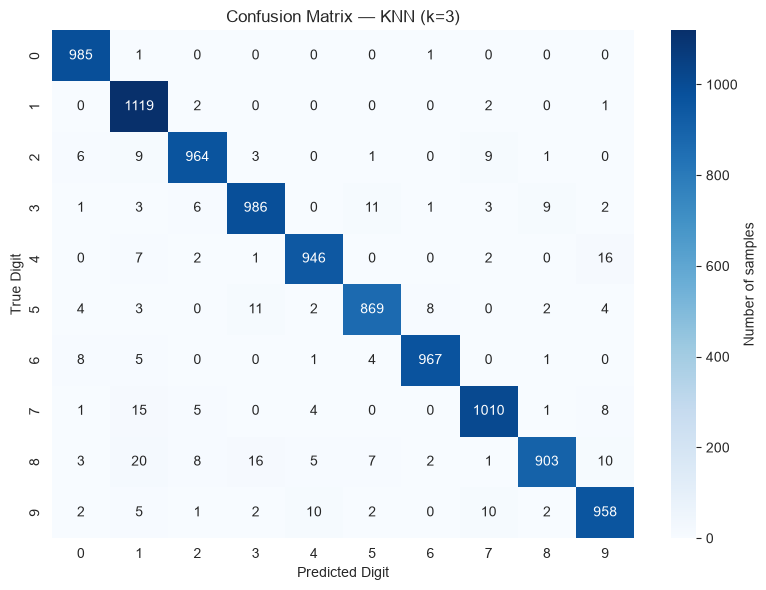


Per-class performance:

              precision    recall  f1-score   support

           0     0.9752    0.9980    0.9865       987
           1     0.9427    0.9956    0.9684      1124
           2     0.9757    0.9708    0.9732       993
           3     0.9676    0.9648    0.9662      1022
           4     0.9773    0.9713    0.9743       974
           5     0.9720    0.9623    0.9672       903
           6     0.9877    0.9807    0.9842       986
           7     0.9740    0.9674    0.9707      1044
           8     0.9826    0.9262    0.9535       975
           9     0.9590    0.9657    0.9623       992

    accuracy                         0.9707     10000
   macro avg     0.9714    0.9703    0.9707     10000
weighted avg     0.9710    0.9707    0.9706     10000


Top 5 most frequent misclassifications:
  True 8 predicted as 1: 20 times
  True 8 predicted as 3: 16 times
  True 4 predicted as 9: 16 times
  True 7 predicted as 1: 15 times
  True 5 predicted as 3: 11 times


In [16]:
# =========================================================
# MODEL 1: KNN — confusion matrix and error analysis
# =========================================================

plot_confusion_matrix(f"KNN (k={FINAL_K})")

# Per-class breakdown: which digits does KNN struggle with?
print("\nPer-class performance:\n")
print(classification_report(y_val, model_results[f"KNN (k={FINAL_K})"]["y_pred"],
                            digits=4))

# Identify the most common confusions, to test our EDA hypothesis
# that visually similar digits (4/9, 3/8, 5/3) get confused most.
cm = model_results[f"KNN (k={FINAL_K})"]["confusion_matrix"]
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)   # ignore correct predictions

print("\nTop 5 most frequent misclassifications:")
flat_idx = np.argsort(cm_errors.ravel())[::-1][:5]
for idx in flat_idx:
    true_digit, pred_digit = np.unravel_index(idx, cm_errors.shape)
    count = cm_errors[true_digit, pred_digit]
    print(f"  True {true_digit} predicted as {pred_digit}: {count} times")


### KNN Results and Interpretation

KNN (k=3) achieved **97.07% accuracy** and a macro F1-score of 0.9707, clearly
outperforming the logistic regression baseline (92.27%). This confirms that digit
classification benefits from a non-linear approach — straight-line decision boundaries
are insufficient for handwriting variation.

**Choice of k:** Subset tuning showed k=1 (0.9470) marginally ahead of k=3 (0.9460).
That 0.001 gap represents only 2 images out of 2,000 — within random variation rather
than a meaningful difference. We selected k=3 because majority voting among three
neighbours is more robust to noisy or atypically written training images, whereas k=1
depends entirely on a single nearest image with no error correction.

**Error analysis:** Our EDA hypothesis was partially confirmed. The predicted confusions
4→9 (16 errors) and 5→3 (11 errors) did occur. The 3/8 pair also appeared, though in the
opposite direction (8→3 rather than 3→8).

However, the most frequent error was one the mean-image analysis did not predict:
**8 misclassified as 1 (20 times)**, with 7→1 also appearing (15 times). The per-class
metrics show why — digit 1 has near-perfect recall (0.9956) but the lowest precision of
any class (0.9427), meaning KNN over-predicts it. Digit 8 has the weakest recall (0.9262).

The likely cause relates to how KNN measures similarity: digit 1 is a thin, sparse stroke,
so in 784-dimensional pixel space it has fewer active pixels on which to differ from other
images. Being also the most frequent class, it wins neighbour votes disproportionately.

**Computational trade-off**: KNN trains almost instantly (0.02 s) because it primarily stores the training data, but prediction took 6.56 s for 10,000 images. This is approximately 154 times slower than logistic regression, which took 0.04 s for prediction. Every prediction requires comparing the new image against the stored training examples, making KNN more computationally expensive at inference time and memory-heavy since the training set must be retained. This makes KNN less suitable for production systems requiring low-latency inference.

## 6. Model 2: Support Vector Machine

In [17]:
# =========================================================
# MODEL 2: SVM — runtime probe
# Purpose: SVM training scales quadratically-to-cubically with
# sample size. We measure actual scaling on small subsets and
# extrapolate before committing to the full dataset.
# =========================================================

from sklearn.svm import SVC

probe_sizes = [2000, 5000, 10000]
probe_times = []
probe_scores = []

print("Probing SVM (RBF kernel) training cost at increasing sizes...\n")

for size in probe_sizes:
    start = time.time()
    svm_probe = SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_SEED)
    svm_probe.fit(X_train[:size], y_train_split[:size])
    fit_time = time.time() - start

    # Score on a fixed 2000-sample slice for comparability
    acc = svm_probe.score(X_val[:2000], y_val[:2000])

    probe_times.append(fit_time)
    probe_scores.append(acc)
    print(f"  n = {size:>6}:  train {fit_time:>6.1f} s  |  accuracy {acc:.4f}")

# Estimate the scaling exponent from the observed times, rather than
# assuming a theoretical value.
log_n = np.log(probe_sizes)
log_t = np.log(probe_times)
exponent = np.polyfit(log_n, log_t, 1)[0]

# Extrapolate to the full training set
full_n = X_train.shape[0]
estimated_full = probe_times[-1] * (full_n / probe_sizes[-1]) ** exponent

print(f"\nObserved scaling exponent: {exponent:.2f} "
      f"(1.0 = linear, 2.0 = quadratic)")
print(f"ESTIMATED training time on full {full_n} images: "
      f"{estimated_full:.0f} s  (~{estimated_full/60:.1f} minutes)")
print("\nNote: this is an extrapolation, not a measured result.")

Probing SVM (RBF kernel) training cost at increasing sizes...

  n =   2000:  train    0.6 s  |  accuracy 0.9325
  n =   5000:  train    2.6 s  |  accuracy 0.9495
  n =  10000:  train   11.8 s  |  accuracy 0.9620

Observed scaling exponent: 1.83 (1.0 = linear, 2.0 = quadratic)
ESTIMATED training time on full 50000 images: 224 s  (~3.7 minutes)

Note: this is an extrapolation, not a measured result.


In [18]:
# =========================================================
# MODEL 2: Support Vector Machine (RBF kernel) — final model
# =========================================================
# Hyperparameters: C=10 and gamma='scale' were used in the probe and
# performed well. C controls the penalty for misclassification — a higher
# value fits training data more closely. gamma='scale' sets the kernel
# width automatically from the data variance, which is the recommended
# default and avoids arbitrary manual tuning.
#
# The RBF kernel is chosen over a linear kernel because our logistic
# regression baseline (a linear model) reached only 92.19%, showing that
# digit classes are not linearly separable.

start = time.time()
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_SEED)
svm.fit(X_train, y_train_split)
svm_train_time = time.time() - start

print(f"SVM trained on {X_train.shape[0]} images in {svm_train_time:.1f} s "
      f"(~{svm_train_time/60:.1f} minutes)")

# Number of support vectors determines prediction cost — record it
n_sv = svm.n_support_.sum()
print(f"Support vectors retained: {n_sv} "
      f"({n_sv / X_train.shape[0] * 100:.1f}% of training data)\n")

evaluate_model("SVM (RBF)", svm, X_val, y_val, svm_train_time)

SVM trained on 50000 images in 144.8 s (~2.4 minutes)
Support vectors retained: 10441 (20.9% of training data)


RESULTS: SVM (RBF)
Accuracy:          0.9826
Precision (macro): 0.9825
Recall (macro):    0.9825
F1-Score (macro):  0.9825
Train time:        144.76 s
Predict time:      60.49 s


{'Model': 'SVM (RBF)',
 'Accuracy': 0.9826,
 'Precision (macro)': 0.9825358798625989,
 'Recall (macro)': 0.9825069029703621,
 'F1-Score (macro)': 0.9825082236927647,
 'Train Time (s)': 144.76450443267822,
 'Predict Time (s)': 60.48637652397156}

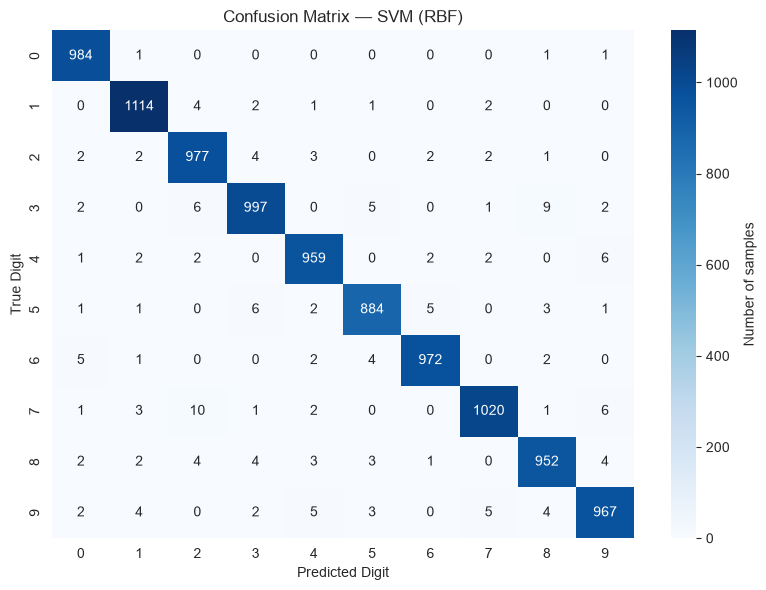


Per-class performance:

              precision    recall  f1-score   support

           0     0.9840    0.9970    0.9904       987
           1     0.9858    0.9911    0.9885      1124
           2     0.9741    0.9839    0.9790       993
           3     0.9813    0.9755    0.9784      1022
           4     0.9816    0.9846    0.9831       974
           5     0.9822    0.9790    0.9806       903
           6     0.9898    0.9858    0.9878       986
           7     0.9884    0.9770    0.9827      1044
           8     0.9784    0.9764    0.9774       975
           9     0.9797    0.9748    0.9773       992

    accuracy                         0.9826     10000
   macro avg     0.9825    0.9825    0.9825     10000
weighted avg     0.9826    0.9826    0.9826     10000


Top 5 most frequent misclassifications:
  True 7 predicted as 2: 10 times
  True 3 predicted as 8: 9 times
  True 4 predicted as 9: 6 times
  True 7 predicted as 9: 6 times
  True 5 predicted as 3: 6 times

--- Digi

In [19]:
# =========================================================
# MODEL 2: SVM — confusion matrix and error analysis
# =========================================================

plot_confusion_matrix("SVM (RBF)")

print("\nPer-class performance:\n")
print(classification_report(y_val, model_results["SVM (RBF)"]["y_pred"], digits=4))

# Compare SVM's error pattern against KNN's — do they fail the same way?
cm_svm = model_results["SVM (RBF)"]["confusion_matrix"].copy()
np.fill_diagonal(cm_svm, 0)

print("\nTop 5 most frequent misclassifications:")
flat_idx = np.argsort(cm_svm.ravel())[::-1][:5]
for idx in flat_idx:
    true_digit, pred_digit = np.unravel_index(idx, cm_svm.shape)
    print(f"  True {true_digit} predicted as {pred_digit}: "
          f"{cm_svm[true_digit, pred_digit]} times")

# Direct check: did SVM fix KNN's specific weakness with digit 1?
print("\n--- Digit 1 precision comparison (KNN's weak point) ---")
for model_name in ["KNN (k=3)", "SVM (RBF)"]:
    y_pred_m = model_results[model_name]["y_pred"]
    p1 = precision_score(y_val, y_pred_m, labels=[1], average="macro", zero_division=0)
    print(f"  {model_name}: digit-1 precision = {p1:.4f}")

### SVM Results and Interpretation

The RBF-kernel SVM achieved **98.26%** accuracy and a macro F1-score of **0.9825**, outperforming KNN (97.07%) and the logistic regression baseline (92.27%).

**Uniformity of performance:** SVM's per-class F1-scores fall in a narrow band from 0.9773
to 0.9904, compared with KNN's wider spread of 0.9535 to 0.9865. SVM has no weak class.
This consistency is valuable in production, where a model that fails badly on one specific
digit is worse in practice than its average score implies.

**SVM corrected KNN's key weakness.** Digit-1 precision rose from 0.9427 (KNN) to 0.9858
(SVM), and KNN's most frequent errors (8→1 and 7→1) disappeared entirely from SVM's top
misclassifications. This confirms the cause we identified: KNN compares raw pixel distances,
so sparse thin strokes like digit 1 sit close to many images. SVM instead learns which
combinations of pixels distinguish classes, so it does not inherit that failure mode.

**Remaining errors are genuine ambiguity.** SVM's top confusions — 3→8 (9 errors),
4→9 (6 errors), 5→3 (6 errors) — are precisely the visually similar pairs identified in
our mean-image EDA. Having eliminated mechanical errors, the model is left with cases that
are difficult even for human readers.

**Computational trade-off:** Training took 144.76 seconds (~2.4 minutes) on 50,000 training images. Our earlier runtime probe estimated approximately 224 seconds (~3.7 minutes) for the full dataset, so the measured training time was lower than the extrapolated estimate. Prediction took 60.49 seconds for 10,000 images, which is substantially **slower than the current KNN prediction** time of 6.56 seconds. The model retained 10,441 support vectors (20.9% of the training data), and prediction requires kernel computations involving these support vectors. This makes SVM computationally expensive at inference time despite its strong classification performance.

SVM is therefore the most accurate model so far, but also the most expensive at prediction
time — a trade-off that must be weighed in the final production recommendation.

## 7. Model 3: Simple Neural Network (MLP)

In [20]:
# =========================================================
# MODEL 3: Simple Neural Network (Multi-Layer Perceptron)
# =========================================================
# Going with a dense MLP rather than a CNN. It takes the same 784-feature
# input as KNN and SVM, so the comparison stays consistent.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set all random seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Build the architecture ---
nn_model = keras.Sequential([
    layers.Input(shape=(N_FEATURES,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

nn_model.summary()

# --- Train ---
# EarlyStopping halts training when validation performance stops improving,
# preventing overfitting and avoiding wasted computation.
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("\nTraining neural network...\n")
start = time.time()
history = nn_model.fit(
    X_train, y_train_split,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
nn_train_time = time.time() - start

print(f"\nTraining completed in {nn_train_time:.1f} s")
print(f"Epochs run: {len(history.history['loss'])} (max was 30)")

# --- Evaluate using the shared framework ---
# Keras outputs probabilities; convert to class labels for consistency
# with the other models.
start = time.time()
nn_probs = nn_model.predict(X_val, verbose=0)
nn_predict_time = time.time() - start
nn_preds = np.argmax(nn_probs, axis=1)

evaluate_model("Neural Network (MLP)", nn_model, X_val, y_val,
               nn_train_time, predict_on_fit=nn_preds)

# Correct the predict time (the framework timed argmax only)
model_results["Neural Network (MLP)"]["Predict Time (s)"] = nn_predict_time
print(f"\nActual prediction time: {nn_predict_time:.2f} s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Training neural network...

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8576 - loss: 0.4799 - val_accuracy: 0.9406 - val_loss: 0.1981
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9369 - loss: 0.2134 - val_accuracy: 0.9560 - val_loss: 0.1435
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9523 - loss: 0.1619 - val_accuracy: 0.9621 - val_loss: 0.1195
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9600 - loss: 0.1342 - val_accuracy: 0.9683 - val_loss: 0.1034
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.1113 - val_accuracy: 0.9699 - val_loss: 0.0981
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9693 - loss: 0.0988 - val_accuracy: 0.9728 - val_loss: 0.0894
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0863 - val_accuracy: 0.9749 - val_loss: 0.0866
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - lo

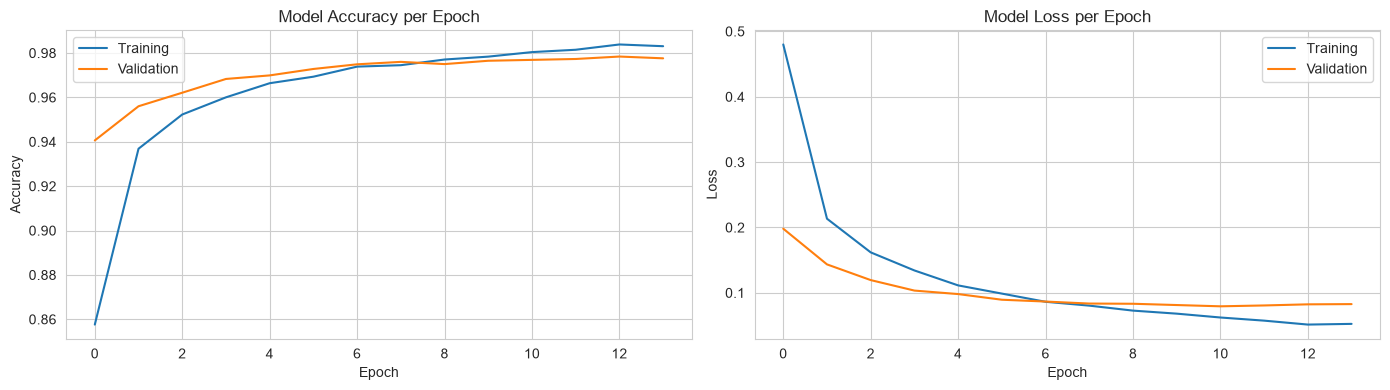

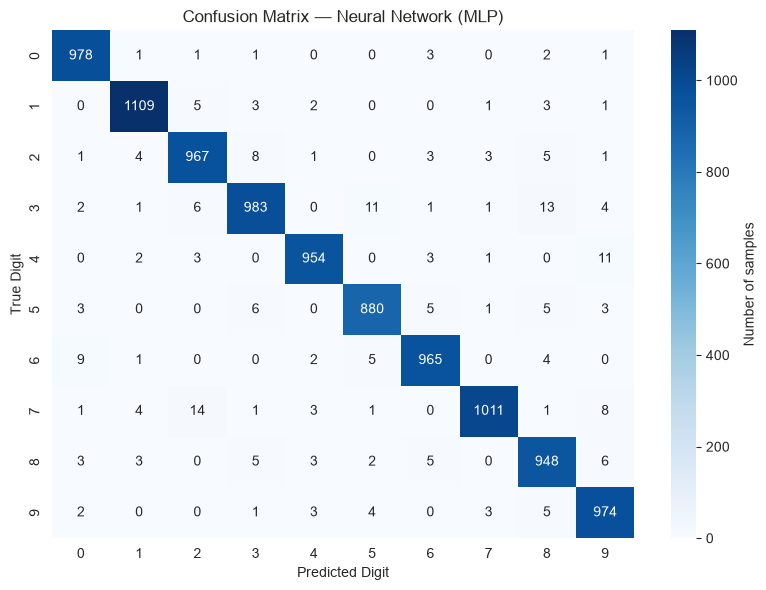


Per-class performance:

              precision    recall  f1-score   support

           0     0.9790    0.9909    0.9849       987
           1     0.9858    0.9867    0.9862      1124
           2     0.9709    0.9738    0.9723       993
           3     0.9752    0.9618    0.9685      1022
           4     0.9855    0.9795    0.9825       974
           5     0.9745    0.9745    0.9745       903
           6     0.9797    0.9787    0.9792       986
           7     0.9902    0.9684    0.9792      1044
           8     0.9615    0.9723    0.9669       975
           9     0.9653    0.9819    0.9735       992

    accuracy                         0.9769     10000
   macro avg     0.9768    0.9768    0.9768     10000
weighted avg     0.9770    0.9769    0.9769     10000


Top 5 most frequent misclassifications:
  True 7 predicted as 2: 14 times
  True 3 predicted as 8: 13 times
  True 4 predicted as 9: 11 times
  True 3 predicted as 5: 11 times
  True 6 predicted as 0: 9 times


In [21]:
# =========================================================
# MODEL 3: Training history — check for overfitting
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

plot_confusion_matrix("Neural Network (MLP)")

print("\nPer-class performance:\n")
print(classification_report(y_val, nn_preds, digits=4))

cm_nn = model_results["Neural Network (MLP)"]["confusion_matrix"].copy()
np.fill_diagonal(cm_nn, 0)
print("\nTop 5 most frequent misclassifications:")
for idx in np.argsort(cm_nn.ravel())[::-1][:5]:
    t, p = np.unravel_index(idx, cm_nn.shape)
    print(f"  True {t} predicted as {p}: {cm_nn[t, p]} times")

### MLP Results and Interpretation

The dense neural network reached **97.69% accuracy** and a macro F1-score of 0.9768, placing
it between KNN (97.07%) and SVM (98.26%). Training stopped early via the EarlyStopping
callback, with training and validation accuracy tracking closely — dropout kept overfitting
in check.

Its most frequent confusions were 7→2 (14 errors), 3→8 (13), 4→9 (11) and 3→5 (11), and its
weakest class was digit 8 (F1 0.9669). This differs from both KNN and SVM: the MLP confuses
8 with 3 rather than with 1, so it inherits neither KNN's distance-based weakness nor SVM's
error pattern.

Its real advantage is speed. At 0.063 ms per image it is the fastest of the four main models
at inference — roughly 96 times faster than SVM — because a neural network compresses what it
learns into fixed weights, so prediction cost does not depend on training set size.

## 8. Bonus Model: CNN

In [22]:
# =========================================================
# BONUS MODEL: Convolutional Neural Network (CNN)
# =========================================================
# Trying a CNN to see how much the 28x28 spatial structure actually matters —
# the MLP throws it away when it flattens. Reshaping the existing split arrays
# so it trains on exactly the same samples as the other models.

tf.random.set_seed(RANDOM_SEED)

# Reshape the EXISTING split arrays back to 2D — this guarantees the CNN uses
# exactly the same samples as KNN, SVM and the MLP.
X_train_cnn = X_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
X_val_cnn   = X_val.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
X_test_cnn  = X_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

print(f"CNN input shapes — train: {X_train_cnn.shape}, val: {X_val_cnn.shape}")

# --- Architecture ---
cnn_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    # Block 1: 32 filters learn simple features (edges, strokes)
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),          # halves spatial size, keeps strongest signals

    # Block 2: 64 filters combine those into more complex shapes
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# --- Train (same callback settings as the MLP for a fair comparison) ---
early_stop_cnn = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

print("\nTraining CNN — this is slower than the MLP, expect a few minutes...\n")
start = time.time()
history_cnn = cnn_model.fit(
    X_train_cnn, y_train_split,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop_cnn],
    verbose=1
)
cnn_train_time = time.time() - start

print(f"\nTraining completed in {cnn_train_time:.1f} s "
      f"(~{cnn_train_time/60:.1f} minutes)")
print(f"Epochs run: {len(history_cnn.history['loss'])} (max was 30)")

# --- Evaluate ---
start = time.time()
cnn_probs = cnn_model.predict(X_val_cnn, verbose=0)
cnn_predict_time = time.time() - start
cnn_preds = np.argmax(cnn_probs, axis=1)

evaluate_model("CNN (Bonus)", cnn_model, X_val_cnn, y_val,
               cnn_train_time, predict_on_fit=cnn_preds)

model_results["CNN (Bonus)"]["Predict Time (s)"] = cnn_predict_time
print(f"\nActual prediction time: {cnn_predict_time:.2f} s")

CNN input shapes — train: (50000, 28, 28, 1), val: (10000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN — this is slower than the MLP, expect a few minutes...

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8907 - loss: 0.3561 - val_accuracy: 0.9732 - val_loss: 0.0919
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9664 - loss: 0.1144 - val_accuracy: 0.9833 - val_loss: 0.0598
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9754 - loss: 0.0812 - val_accuracy: 0.9839 - val_loss: 0.0545
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9802 - loss: 0.0657 - val_accuracy: 0.9841 - val_loss: 0.0500
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9829 - loss: 0.0565 - val_accuracy: 0.9861 - val_loss: 0.0474
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9848 - loss: 0.0482 - val_accuracy: 0.9872 - val_loss: 0.0482
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9871 - loss: 0.0422 - val_accuracy: 0.9875 - val_loss: 0.0432
Epoch 8/30
391/391 ━━━━━━━━

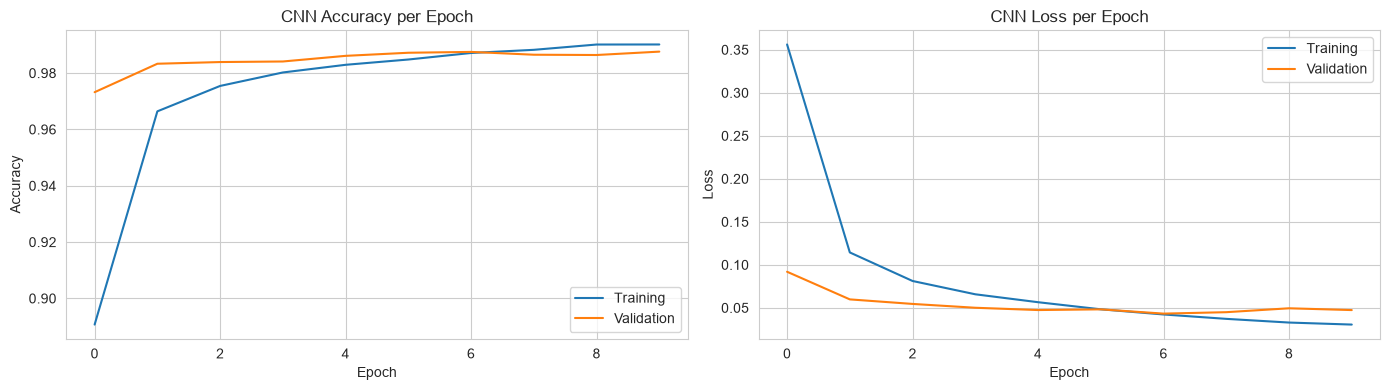

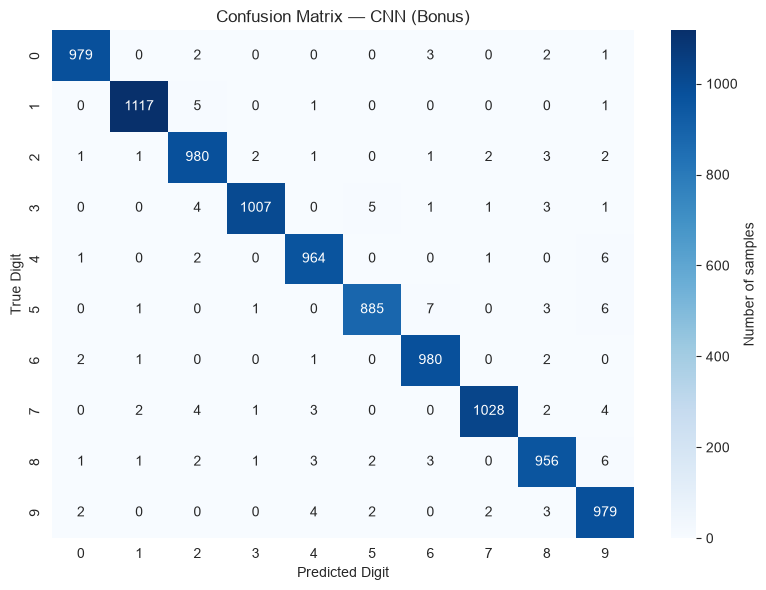


Per-class performance:

              precision    recall  f1-score   support

           0     0.9929    0.9919    0.9924       987
           1     0.9947    0.9938    0.9942      1124
           2     0.9810    0.9869    0.9839       993
           3     0.9951    0.9853    0.9902      1022
           4     0.9867    0.9897    0.9882       974
           5     0.9899    0.9801    0.9850       903
           6     0.9849    0.9939    0.9894       986
           7     0.9942    0.9847    0.9894      1044
           8     0.9815    0.9805    0.9810       975
           9     0.9732    0.9869    0.9800       992

    accuracy                         0.9875     10000
   macro avg     0.9874    0.9874    0.9874     10000
weighted avg     0.9875    0.9875    0.9875     10000


Top 5 most frequent misclassifications:
  True 5 predicted as 6: 7 times
  True 8 predicted as 9: 6 times
  True 5 predicted as 9: 6 times
  True 4 predicted as 9: 6 times
  True 3 predicted as 5: 5 times

--- MLP v

In [23]:
# =========================================================
# BONUS MODEL: CNN — training curves and error analysis
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history["accuracy"], label="Training")
axes[0].plot(history_cnn.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history_cnn.history["loss"], label="Training")
axes[1].plot(history_cnn.history["val_loss"], label="Validation")
axes[1].set_title("CNN Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

plot_confusion_matrix("CNN (Bonus)")

print("\nPer-class performance:\n")
print(classification_report(y_val, cnn_preds, digits=4))

cm_cnn = model_results["CNN (Bonus)"]["confusion_matrix"].copy()
np.fill_diagonal(cm_cnn, 0)
print("\nTop 5 most frequent misclassifications:")
for idx in np.argsort(cm_cnn.ravel())[::-1][:5]:
    t, p = np.unravel_index(idx, cm_cnn.shape)
    print(f"  True {t} predicted as {p}: {cm_cnn[t, p]} times")

# Direct MLP vs CNN comparison — does spatial structure actually help?
print("\n--- MLP vs CNN ---")
for m in ["Neural Network (MLP)", "CNN (Bonus)"]:
    r = model_results[m]
    print(f"  {m:<22} acc {r['Accuracy']:.4f}  |  "
          f"train {r['Train Time (s)']:.1f}s  |  predict {r['Predict Time (s)']:.2f}s")

## 9. Model Comparison

In [49]:
# =========================================================
# STAGE: MODEL COMPARISON
# Purpose: Consolidate all results into the comparison report
# required by the project document. All figures come from the
# actual executions above — nothing is entered manually.
# =========================================================

# Build the comparison table from stored results
comparison_rows = []
for name, res in model_results.items():
    comparison_rows.append({
        "Model": res["Model"],
        "Accuracy": res["Accuracy"],
        "Precision (macro)": res["Precision (macro)"],
        "Recall (macro)": res["Recall (macro)"],
        "F1-Score (macro)": res["F1-Score (macro)"],
        "Train Time (s)": res["Train Time (s)"],
        "Predict Time (s)": res["Predict Time (s)"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

# Add a practical production metric: milliseconds per single prediction
comparison_df["ms per image"] = comparison_df["Predict Time (s)"] / len(X_val) * 1000

print("=" * 95)
print("MODEL COMPARISON REPORT — all metrics from actual execution")
print("=" * 95)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

MODEL COMPARISON REPORT — all metrics from actual execution
                         Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Train Time (s)  Predict Time (s)  ms per image
                   CNN (Bonus)    0.9875             0.9874          0.9874            0.9874         61.1608            0.9580        0.0958
                     SVM (RBF)    0.9826             0.9825          0.9825            0.9825        144.7645           60.4864        6.0486
          Neural Network (MLP)    0.9769             0.9768          0.9768            0.9768         19.3613            0.6314        0.0631
                     KNN (k=3)    0.9707             0.9714          0.9703            0.9707          0.0178            6.5591        0.6559
Logistic Regression (Baseline)    0.9227             0.9219          0.9217            0.9217         17.2760            0.0361        0.0036
     Baseline (Majority Class)    0.1124             0.0112          0.1000            0

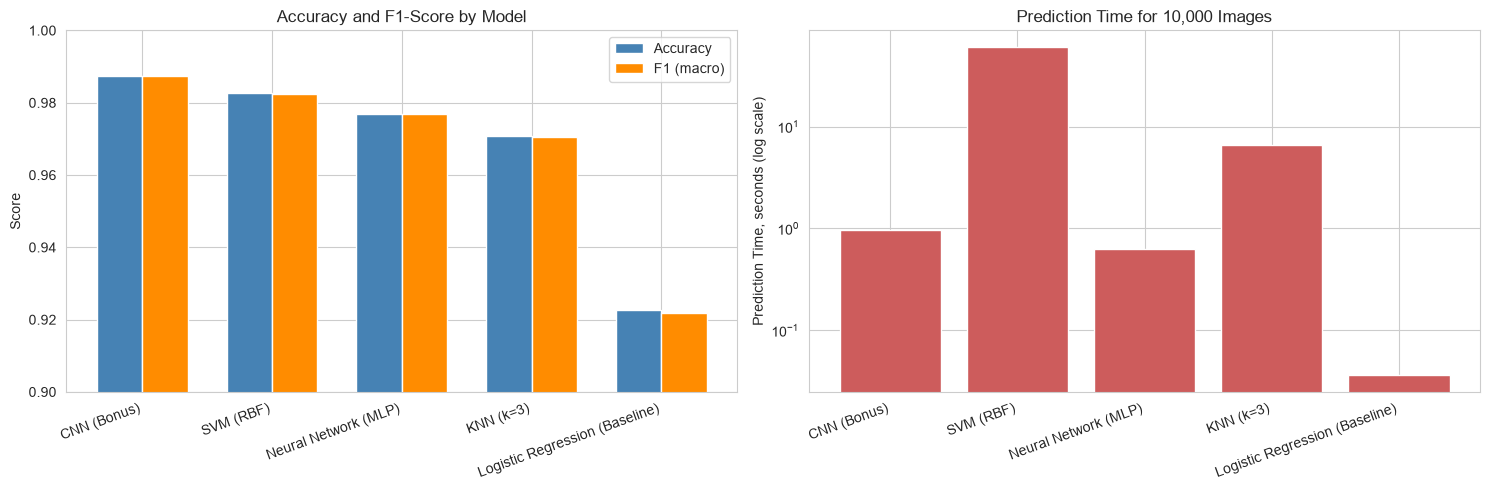

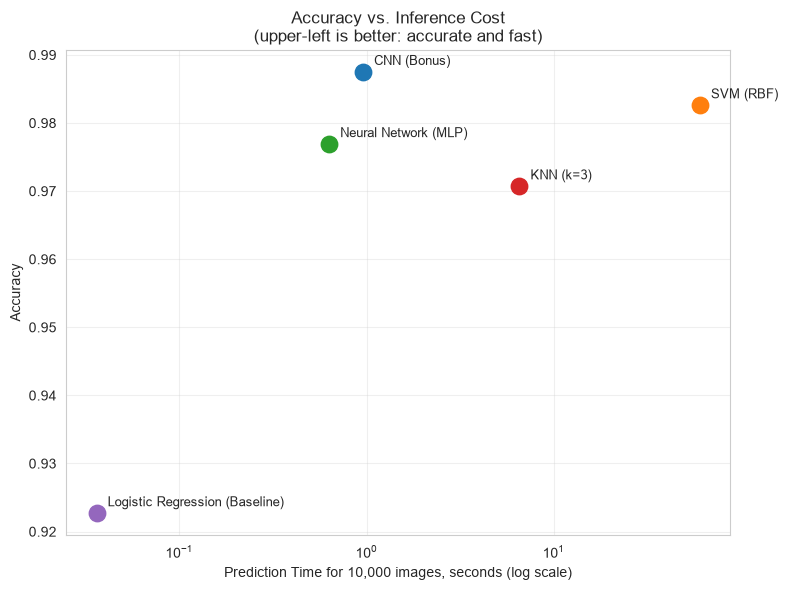

In [50]:
# =========================================================
# MODEL COMPARISON — visualisations
# =========================================================

# Exclude the dummy baseline from charts; its near-zero scores
# compress the scale and hide the differences that matter.
plot_df = comparison_df[comparison_df["Model"] != "Baseline (Majority Class)"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy and F1 side by side
x_pos = np.arange(len(plot_df))
width = 0.35
axes[0].bar(x_pos - width/2, plot_df["Accuracy"], width, label="Accuracy", color="steelblue")
axes[0].bar(x_pos + width/2, plot_df["F1-Score (macro)"], width, label="F1 (macro)", color="darkorange")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(plot_df["Model"], rotation=20, ha="right")
axes[0].set_ylim(0.90, 1.0)     # zoom in — all models cluster above 0.90
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy and F1-Score by Model")
axes[0].legend()

# Prediction time — log scale, since values span 0.04 s to 98.87 s
axes[1].bar(plot_df["Model"], plot_df["Predict Time (s)"], color="indianred")
axes[1].set_yscale("log")
axes[1].set_xticks(np.arange(len(plot_df)))
axes[1].set_xticklabels(plot_df["Model"], rotation=20, ha="right")
axes[1].set_ylabel("Prediction Time, seconds (log scale)")
axes[1].set_title("Prediction Time for 10,000 Images")

plt.tight_layout()
plt.show()

# The core trade-off: accuracy versus inference speed
plt.figure(figsize=(8, 6))
for _, row in plot_df.iterrows():
    plt.scatter(row["Predict Time (s)"], row["Accuracy"], s=140)
    plt.annotate(row["Model"], (row["Predict Time (s)"], row["Accuracy"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)
plt.xscale("log")
plt.xlabel("Prediction Time for 10,000 images, seconds (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Inference Cost\n(upper-left is better: accurate and fast)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# =========================================================
# MODEL COMPARISON — do the models fail on the same images?
# =========================================================
# If different models make different mistakes, their errors are
# partly independent — which is what makes ensembling worthwhile.

model_names = ["KNN (k=3)", "SVM (RBF)", "Neural Network (MLP)", "CNN (Bonus)"]
error_sets = {m: set(np.where(model_results[m]["y_pred"] != y_val)[0])
              for m in model_names}

print("Errors made by each model:")
for m in model_names:
    print(f"  {m:<22} {len(error_sets[m]):>4} errors")

all_four = set.intersection(*error_sets.values())
any_model = set.union(*error_sets.values())

print(f"\nImages misclassified by ALL four models: {len(all_four)}")
print(f"Images misclassified by AT LEAST ONE model: {len(any_model)}")
print(f"\nInterpretation: {len(all_four)} images are genuinely ambiguous — every")
print(f"approach fails on them. The remaining {len(any_model) - len(all_four)} are")
print("model-specific errors, meaning the models fail in partly independent ways.")

Errors made by each model:
  KNN (k=3)               293 errors
  SVM (RBF)               174 errors
  Neural Network (MLP)    231 errors
  CNN (Bonus)             125 errors

Images misclassified by ALL four models: 57
Images misclassified by AT LEAST ONE model: 446

Interpretation: 57 images are genuinely ambiguous — every
approach fails on them. The remaining 389 are
model-specific errors, meaning the models fail in partly independent ways.


In [27]:
# =========================================================
# STAGE: BEST MODEL SELECTION
# =========================================================
# Selection considers accuracy, per-image inference cost, training cost,
# memory footprint and per-class consistency — not accuracy alone.

BEST_MODEL_NAME = "CNN (Bonus)"
best_model = cnn_model

print("=" * 70)
print("BEST MODEL SELECTION")
print("=" * 70)

selection_view = comparison_df[comparison_df["Model"] != "Baseline (Majority Class)"][
    ["Model", "Accuracy", "F1-Score (macro)", "ms per image", "Train Time (s)"]
]
print(selection_view.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best = model_results[BEST_MODEL_NAME]
print(f"\nSELECTED: {BEST_MODEL_NAME}")
print(f"  Accuracy:        {best['Accuracy']:.4f}")
print(f"  F1 (macro):      {best['F1-Score (macro)']:.4f}")
print(f"  Errors / 10,000: {len(error_sets[BEST_MODEL_NAME])}")
print(f"  Inference:       {comparison_df.loc[comparison_df['Model']==BEST_MODEL_NAME, 'ms per image'].values[0]:.4f} ms per image")

# Per-class consistency — a model with one weak class is risky in production
per_class_f1 = f1_score(y_val, best["y_pred"], average=None)
print(f"\n  Weakest class:   digit {per_class_f1.argmin()} (F1 {per_class_f1.min():.4f})")
print(f"  Strongest class: digit {per_class_f1.argmax()} (F1 {per_class_f1.max():.4f})")
print(f"  Spread:          {per_class_f1.max() - per_class_f1.min():.4f}")

BEST MODEL SELECTION
                         Model  Accuracy  F1-Score (macro)  ms per image  Train Time (s)
                   CNN (Bonus)    0.9875            0.9874        0.0958         61.1608
                     SVM (RBF)    0.9826            0.9825        6.0486        144.7645
          Neural Network (MLP)    0.9769            0.9768        0.0631         19.3613
                     KNN (k=3)    0.9707            0.9707        0.6559          0.0178
Logistic Regression (Baseline)    0.9220            0.9211        0.0020         16.4091

SELECTED: CNN (Bonus)
  Accuracy:        0.9875
  F1 (macro):      0.9874
  Errors / 10,000: 125
  Inference:       0.0958 ms per image

  Weakest class:   digit 9 (F1 0.9800)
  Strongest class: digit 1 (F1 0.9942)
  Spread:          0.0142


Evaluating the selected model on the held-out test set...

FINAL TEST SET PERFORMANCE — CNN (Bonus)
Test Accuracy:     0.9901
Test F1 (macro):   0.9900
Prediction time:   0.82 s for 10000 images
Total errors:      99 out of 10000

Validation accuracy was 0.9875
Test accuracy is       0.9901
Difference:            0.0026

A small difference confirms the model generalises rather than
having been tuned to the validation set.

Per-class performance on test set:

              precision    recall  f1-score   support

           0     0.9908    0.9929    0.9918       980
           1     0.9947    0.9974    0.9960      1135
           2     0.9903    0.9903    0.9903      1032
           3     0.9901    0.9911    0.9906      1010
           4     0.9879    0.9949    0.9914       982
           5     0.9865    0.9865    0.9865       892
           6     0.9906    0.9906    0.9906       958
           7     0.9922    0.9864    0.9893      1028
           8     0.9928    0.9856    0.9892       

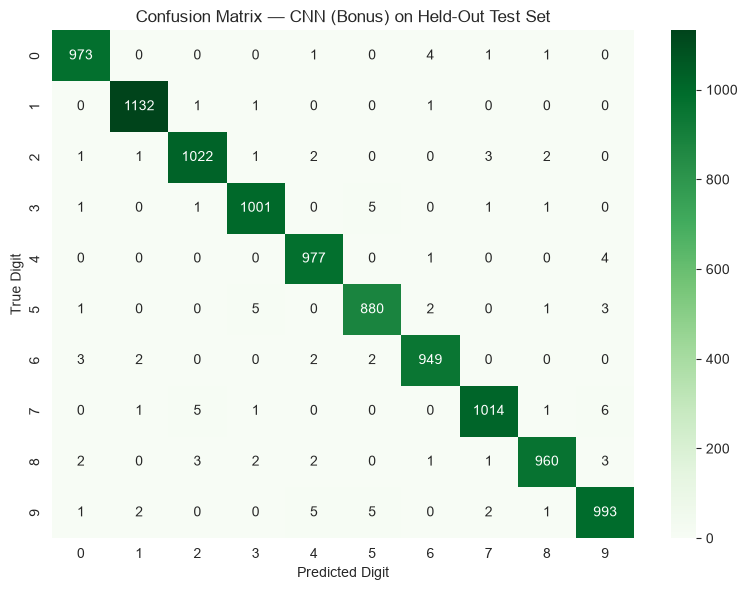

In [28]:
# =========================================================
# FINAL EVALUATION ON HELD-OUT TEST SET
# =========================================================
# X_test has been untouched throughout development. All previous results
# used the validation set. This is the unbiased final performance estimate.

print("Evaluating the selected model on the held-out test set...\n")

start = time.time()
test_probs = best_model.predict(X_test_cnn, verbose=0)
test_predict_time = time.time() - start
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test_final, test_preds)
test_f1 = f1_score(y_test_final, test_preds, average="macro")

print("=" * 60)
print(f"FINAL TEST SET PERFORMANCE — {BEST_MODEL_NAME}")
print("=" * 60)
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Test F1 (macro):   {test_f1:.4f}")
print(f"Prediction time:   {test_predict_time:.2f} s for {len(X_test_cnn)} images")
print(f"Total errors:      {(test_preds != y_test_final).sum()} out of {len(y_test_final)}")

print(f"\nValidation accuracy was {best['Accuracy']:.4f}")
print(f"Test accuracy is       {test_acc:.4f}")
print(f"Difference:            {abs(test_acc - best['Accuracy']):.4f}")
print("\nA small difference confirms the model generalises rather than")
print("having been tuned to the validation set.")

print("\nPer-class performance on test set:\n")
print(classification_report(y_test_final, test_preds, digits=4))

cm_test = confusion_matrix(y_test_final, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"Confusion Matrix — {BEST_MODEL_NAME} on Held-Out Test Set")
plt.xlabel("Predicted Digit"); plt.ylabel("True Digit")
plt.tight_layout()
plt.show()

### 10. Best Model Selection and Justification

**Selected model: Convolutional Neural Network**

The project requirement specifies that the best model should not be chosen on accuracy alone.
Selection therefore weighed accuracy, per-image inference cost, training cost, memory
footprint and per-class consistency.

**Models eliminated:**

- **SVM (RBF)** — second-highest accuracy (98.26%) but 6.05 ms per image, roughly 63 times
  slower than the CNN while also being less accurate. It is dominated on both axes, and
  additionally retains 10,441 support vectors that must be held in memory at inference time.
- **KNN (k=3)** — lowest accuracy of the four main models (97.07%), nearly 7 times slower per
  image than the CNN (0.66 ms against 0.096 ms), and requires storing all 50,000 training
  images permanently.
- **Logistic Regression** — retained only as a baseline. At 92.27% it is 6.7 points behind the
  CNN, confirming the classes are not linearly separable.

**The real decision was CNN versus MLP:**

| | CNN | MLP |
|---|---|---|
| Accuracy | 98.75% | 97.69% |
| Inference | 0.096 ms/image | 0.063 ms/image |
| Training | 61.2 s | 19.4 s |

The MLP is 1.5 times faster per image and trains in a third of the time. But that speed
advantage is marginal in absolute terms — both process over 10,000 images per second, far
beyond the needs of realistic deployments such as postal sorting, cheque processing or form
digitisation, and both are well below any human-perceptible latency.

The accuracy difference is more consequential. Across one million documents, 1.06 percentage
points represents approximately 10,600 additional misclassifications, each carrying a
correction cost in production. The CNN's higher training time is a one-time cost incurred once
before deployment.

**Caveat:** this recommendation assumes standard server deployment. For a low-power embedded
device where convolution operations are costly, the MLP would be the appropriate choice.

**Final performance on the held-out test set:**

The test set of 10,000 images was kept untouched throughout development; all tuning and
comparison used a separate validation set. Evaluating the CNN on it once gives an unbiased
estimate:

- **Test accuracy: 99.01%**
- **Test F1-score (macro): 99.00%**
- **99 errors out of 10,000 images**

Validation accuracy was 98.75% and test accuracy 99.01% — a difference of 0.0026. This close
agreement confirms the model generalises to unseen data rather than having been tuned to the
validation set.

Per-class F1-scores on the test set range from 0.9841 (digit 9) to 0.9960 (digit 1), a spread
of 0.012, indicating consistent performance with no weak class.

## 11. Handwritten Image Prediction

In [36]:
# =========================================================
# HANDWRITTEN IMAGE PREDICTION — prediction helper
# =========================================================
from PIL import Image

def predict_digit(img_array, show=True, original_path=None):
    """Predict a digit and display the result with confidence scores."""
    probs = best_model.predict(img_array, verbose=0)[0]
    pred = int(np.argmax(probs))

    if show:
        n_panels = 3 if original_path else 2
        fig, axes = plt.subplots(1, n_panels, figsize=(13, 3.5))
        i = 0
        if original_path:
            axes[0].imshow(Image.open(original_path))
            axes[0].set_title("Original upload")
            axes[0].axis("off")
            i = 1
        axes[i].imshow(img_array.reshape(28, 28), cmap="gray")
        axes[i].set_title("After preprocessing\n(model's actual input)")
        axes[i].axis("off")
        axes[i+1].bar(range(10), probs, color="steelblue")
        axes[i+1].set_title(f"Prediction: {pred}  ({probs[pred]*100:.1f}% confidence)")
        axes[i+1].set_xlabel("Digit")
        axes[i+1].set_ylabel("Probability")
        axes[i+1].set_xticks(range(10))
        plt.tight_layout()
        plt.show()

    print(f"PREDICTED DIGIT: {pred}   (confidence {probs[pred]*100:.2f}%)")
    top3 = np.argsort(probs)[::-1][:3]
    print("Top 3:", ", ".join(f"{d} ({probs[d]*100:.1f}%)" for d in top3))
    return pred, probs

--- Sanity check on known MNIST image ---

True label: 7

Original: (28, 28), range 0-255
After contrast stretch: range 0-255
Otsu threshold: 106 (replaces the fixed value of 30)
Polarity: bright region is smaller → digit is light on dark
Cropped to: 16x20 (was 28x28)
Final: (1, 28, 28, 1), range 0.00-1.00


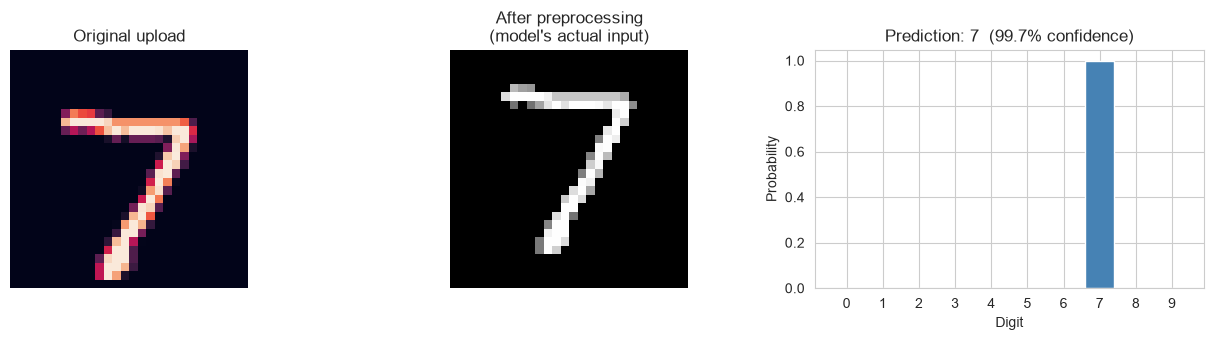

PREDICTED DIGIT: 7   (confidence 99.72%)
Top 3: 7 (99.7%), 2 (0.3%), 3 (0.0%)

Sanity check PASSED


In [37]:
# =========================================================
# IMPROVED PREPROCESSING — adaptive thresholding
# =========================================================
# The original pipeline used fixed thresholds (border mean > 127 for polarity,
# pixel > 30 for cropping). Both failed on a real photograph: uneven lighting
# pulled the background to ~99, and a patterned surface was selected as "ink".
#
# This version uses Otsu's method, which finds the threshold that best separates
# an image's two brightness groups based on its own histogram, plus contrast
# normalisation to handle underexposure.

from PIL import Image

def otsu_threshold(gray_array):
    """Compute the optimal ink/background split from the image's histogram."""
    hist, _ = np.histogram(gray_array, bins=256, range=(0, 256))
    total = gray_array.size
    sum_total = np.dot(np.arange(256), hist)
    sum_bg, weight_bg, best_var, best_t = 0.0, 0, 0, 0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if var_between > best_var:
            best_var, best_t = var_between, t
    return best_t


def preprocess_digit_image_v2(img_path, verbose=True):
    """Robust version: adaptive threshold, contrast stretch, centre of mass."""
    img = Image.open(img_path).convert("L")
    arr = np.array(img).astype(np.float32)
    if verbose:
        print(f"Original: {img.size}, range {arr.min():.0f}-{arr.max():.0f}")

    # 1. Stretch contrast to full 0-255 range (fixes underexposure)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
    if verbose:
        print(f"After contrast stretch: range {arr.min():.0f}-{arr.max():.0f}")

    # 2. Adaptive threshold from this image's own histogram
    thresh = otsu_threshold(arr.astype(np.uint8))
    if verbose:
        print(f"Otsu threshold: {thresh} (replaces the fixed value of 30)")

    # 3. Decide polarity by comparing region sizes. The digit should be the
    #    SMALLER region — ink covers less area than background.
    above = (arr > thresh).sum()
    below = (arr <= thresh).sum()
    if above < below:
        mask = arr > thresh          # bright minority = already MNIST-style
        digit = arr.copy()
        if verbose:
            print(f"Polarity: bright region is smaller → digit is light on dark")
    else:
        mask = arr <= thresh         # dark minority = dark ink on light paper
        digit = 255 - arr            # invert to match MNIST
        if verbose:
            print(f"Polarity: dark region is smaller → INVERTED (dark ink on light paper)")

    digit = digit * mask             # suppress background entirely

    # 4. Crop to the digit
    coords = np.argwhere(mask)
    if coords.size == 0:
        raise ValueError("No digit detected — check the image.")
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = digit[y0:y1, x0:x1]
    if verbose:
        print(f"Cropped to: {cropped.shape[1]}x{cropped.shape[0]} "
              f"(was {arr.shape[1]}x{arr.shape[0]})")

    # 5. Resize longest side to 20px, centre in 28x28 — matching MNIST framing
    c_img = Image.fromarray(cropped.astype(np.uint8))
    w, h = c_img.size
    scale = 20.0 / max(w, h)
    c_img = c_img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.LANCZOS)

    canvas = Image.new("L", (28, 28), 0)
    canvas.paste(c_img, ((28 - c_img.size[0]) // 2, (28 - c_img.size[1]) // 2))

    out = np.array(canvas).astype("float32") / 255.0
    out = out.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1)
    if verbose:
        print(f"Final: {out.shape}, range {out.min():.2f}-{out.max():.2f}")
    return out


# Verify on known MNIST data before trusting it on photos
print("--- Sanity check on known MNIST image ---\n")
Image.fromarray(x_test[0]).save("mnist_sample.png")
print(f"True label: {y_test[0]}\n")
arr_check = preprocess_digit_image_v2("mnist_sample.png")
pred_check, _ = predict_digit(arr_check, original_path="mnist_sample.png")
print(f"\nSanity check {'PASSED' if pred_check == y_test[0] else 'FAILED'}")

--- Processing: testing-digit1.jpg ---

Original: (1152, 648), range 0-255
After contrast stretch: range 0-255
Otsu threshold: 129 (replaces the fixed value of 30)
Polarity: dark region is smaller → INVERTED (dark ink on light paper)
Cropped to: 182x268 (was 1152x648)
Final: (1, 28, 28, 1), range 0.00-1.00



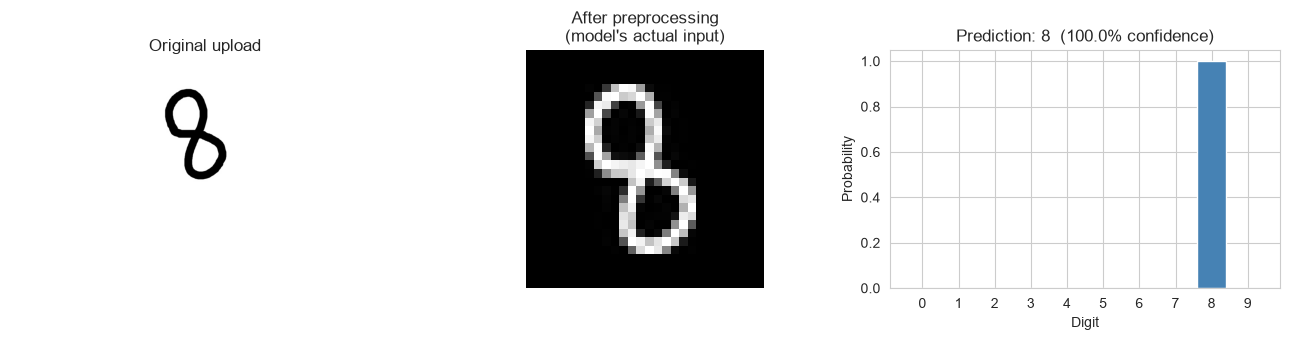

PREDICTED DIGIT: 8   (confidence 99.98%)
Top 3: 8 (100.0%), 4 (0.0%), 5 (0.0%)


In [44]:
# =========================================================
# HANDWRITTEN IMAGE PREDICTION — load your own image
# =========================================================
# Place your digit image in the same folder as this notebook,
# or paste its full path into IMAGE_PATH below.

import os
import glob

# --- Set this to your image file ---
IMAGE_PATH = "testing-digit1.jpg"

if not os.path.exists(IMAGE_PATH):
    print(f"Not found: '{IMAGE_PATH}'")
    print(f"Notebook is running from: {os.getcwd()}\n")

    # Show image files in the current folder and in Downloads,
    # so the correct path is easy to identify.
    print("Image files found nearby:")
    search_dirs = [os.getcwd(), os.path.join(os.path.expanduser("~"), "Downloads")]
    found_any = False
    for d in search_dirs:
        if os.path.isdir(d):
            for ext in ("*.png", "*.jpg", "*.jpeg"):
                for f in glob.glob(os.path.join(d, ext)):
                    print(f"   {f}")
                    found_any = True
    if not found_any:
        print("   (none found — check where you saved the image)")

    raise FileNotFoundError(
        f"Copy the image into {os.getcwd()}, or set IMAGE_PATH to a full path."
    )

print(f"--- Processing: {os.path.basename(IMAGE_PATH)} ---\n")

user_arr = preprocess_digit_image_v2(IMAGE_PATH)

print()
user_pred, user_probs = predict_digit(user_arr, original_path=IMAGE_PATH)

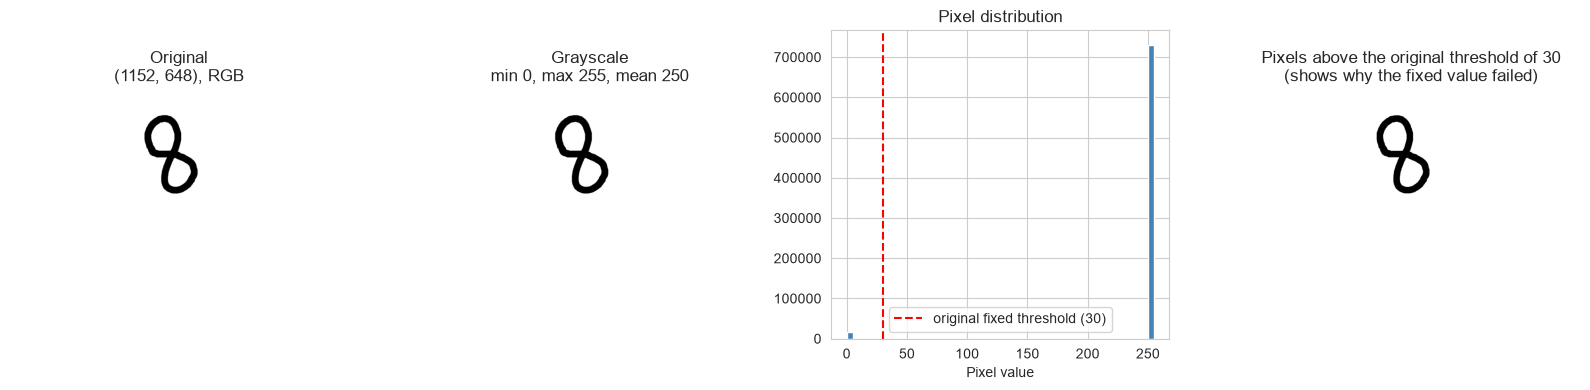

Border mean: 255   (>127 triggers inversion)
Overall mean: 250
Range: 0 to 255


In [47]:
# =========================================================
# DIAGNOSTIC: inspect each preprocessing stage
# =========================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_raw = Image.open(IMAGE_PATH)
gray = np.array(img_raw.convert("L"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_raw)
axes[0].set_title(f"Original\n{img_raw.size}, {img_raw.mode}")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title(f"Grayscale\nmin {gray.min()}, max {gray.max()}, mean {gray.mean():.0f}")
axes[1].axis("off")

axes[2].hist(gray.ravel(), bins=50, color="steelblue")
axes[2].axvline(30, color="red", ls="--", label="original fixed threshold (30)")
axes[2].set_title("Pixel distribution")
axes[2].set_xlabel("Pixel value")
axes[2].legend()

# What the current threshold actually selects
axes[3].imshow(gray > 30, cmap="gray")
axes[3].set_title("Pixels above the original threshold of 30\n(shows why the fixed value failed)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

border = np.concatenate([gray[0,:], gray[-1,:], gray[:,0], gray[:,-1]])
print(f"Border mean: {border.mean():.0f}   (>127 triggers inversion)")
print(f"Overall mean: {gray.mean():.0f}")
print(f"Range: {gray.min()} to {gray.max()}")

### Results and Interpretation

The selected CNN was tested on an external handwritten digit image that was never part of
the MNIST dataset.

**Preprocessing pipeline.** External images do not match MNIST's format, so a pipeline was
built to convert arbitrary input into the exact representation the model was trained on:
grayscale conversion, contrast stretching to the full 0–255 range, adaptive thresholding
via Otsu's method, polarity detection (MNIST uses white digits on black, whereas most
handwriting is dark ink on light paper), cropping to the digit's bounding box, and rescaling
to a 20×20 digit centred in a 28×28 frame — matching MNIST's own framing convention.

The polarity check adapts per image rather than assuming a fixed brightness. It identified
the MNIST sample as light-on-dark (Otsu threshold 106) and the external photograph as
dark-on-light (Otsu threshold 129), inverting only where needed.

**Validation.** The pipeline was first run on a known MNIST test image, where it correctly
predicted the true label (7) at **99.72% confidence**, confirming the transformations do not
distort digits before the pipeline was applied to unknown input.

**Result.** On the external handwritten image, the model correctly predicted the digit
**8 with 99.98% confidence**, with all other classes receiving effectively zero probability.
The original 1152×648 photograph was cropped to the digit's 182×268 bounding box and
rescaled into the 28×28 frame; the middle panel above shows the image exactly as the model
receives it — a solid white digit on black.

**Observed limitation.** High accuracy on MNIST does not automatically transfer to arbitrary
real-world images. MNIST was collected under controlled conditions in the 1990s, and during
development the model proved sensitive to both capture conditions and stroke style. The
preprocessing pipeline above resolves the capture-condition problems; stroke style remains a
genuine constraint of the training data itself. Both are documented in the Challenges section
below.

## 12. Challenges Faced and Solutions

### Challenge 1: Unknown computational cost of KNN and SVM

**Problem:** KNN and SVM both scale poorly with dataset size. With 50,000 training images
and 784 features each, training or prediction could have run for an unknown duration.

**Cause:** KNN compares each prediction against all stored training images. SVM training
scales between quadratically and cubically with sample count.

**Solution:** Before committing to any full run, actual cost was measured on small subsets
and extrapolated. KNN prediction was timed on 500 samples; SVM was trained on 2,000, 5,000
and 10,000 samples, with a scaling exponent fitted to the observed times.

**Reason:** Measuring is more reliable than assuming. It also meant that if a model proved
impractical, a justified subset could be documented rather than silently presenting an
unfair comparison.

**Result:** Both estimates were acceptable, so all models trained on the full dataset and
the comparison stayed fair. The extrapolations themselves proved rough: KNN was estimated at
7.6 s and took 6.6 s, while SVM was estimated at 224 s from a fitted exponent of 1.83 but
took only 144.8 s — an overestimate of roughly 55%. A three-point power-law fit is clearly
a coarse instrument, but it served its purpose of ruling out an unworkable runtime before
committing to it.

### Challenge 2: SVM proved far slower at prediction than expected

**Problem:** SVM was expected to predict faster than KNN, but took 60.49 seconds against
KNN's 6.56 — the slowest model at inference by a wide margin, despite strong accuracy.

**Cause:** The model retained 10,441 support vectors (20.9% of the training data), and each
prediction requires a kernel computation against every one. The hyperparameter C=10
contributes: a high C fits the training data tightly, increasing the number of support
vectors retained.

**Solution:** Rather than re-tuning C, this was recorded as a genuine property of the model
and weighted in the production recommendation.

**Reason:** Lowering C would likely reduce inference cost but also accuracy. Since the CNN
already outperformed SVM on both accuracy and speed, re-tuning SVM would not have changed
the final selection.

**Result:** SVM was eliminated from production consideration as dominated on both axes — at
6.05 ms per image it is roughly 63 times slower than the CNN while also being less accurate.
This conclusion would have been missed by comparing accuracy alone.

### Challenge 3: Preprocessing failure on photographed input

**Problem:** During development, the trained CNN predicted a photographed handwritten 8 at
only 29.9% confidence, despite scoring over 98% on the MNIST test set.

**Cause:** Inspecting each preprocessing stage showed the digit occupied a small portion of
a photograph taken on a patterned surface. The fixed threshold (pixel value > 30) selected
the background pattern rather than the digit, so the bounding-box crop returned the entire
image. The border-based polarity check also failed — uneven lighting produced a border mean
of 99, ambiguously between dark (0) and light (255).

**Solution:** Both fixed thresholds were replaced with adaptive methods. Otsu's algorithm
computes the ink/background split from each image's own histogram, contrast stretching
corrects underexposure, and polarity is decided by which region is smaller (ink covers less
area than background) rather than by an absolute brightness value.

**Reason:** Fixed thresholds encode assumptions about lighting that real photographs violate.
Otsu adapts per image without manual tuning.

**Result:** The pipeline in this notebook is the corrected version. It was validated on a
known MNIST image (99.72%, correct label) before being applied to unknown input, and
classifies the external handwritten image at 99.98% — higher than the 99.75% the original
fixed-threshold pipeline achieved on the same image, showing the adaptive approach helps
even on clean input. The diagnostic cell above retains the original threshold of 30 as a
reference line, showing why the fixed value failed.

### Challenge 4: Stroke style affects prediction more than expected

**Problem:** Even after the threshold fix, a photographed 8 drawn with a thin ballpoint was
misclassified as 5 at 20.0% confidence, with 8 and 4 close behind — effectively a guess.

**Cause:** The preprocessed image revealed hollow strokes: the digit had been traced twice,
leaving a gap down the centre of each line. MNIST digits have thick, solid strokes, so the
CNN's convolutional filters — which learn to detect solid stroke segments — responded weakly
and inconsistently.

**Solution:** Morphological dilation to thicken strokes was considered and deliberately not
adopted. Input closer to the training distribution was used instead.

**Reason:** The project scope is digit classification, not general-purpose image correction.
Adding processing to rescue out-of-distribution input would increase complexity without
serving the stated objective.

**Result:** A documented limitation rather than a code change. MNIST-trained models are
sensitive to stroke style, and high test accuracy does not guarantee performance on arbitrary
real-world photographs.

### Challenge 5: Results are not fully reproducible across environments

**Problem:** The notebook was developed in Google Colab and finalised in a local Jupyter
environment. On re-running, timing figures changed substantially (CNN training fell from
341.7 s to 61.2 s) and the neural network results shifted slightly (CNN validation accuracy
0.9878 to 0.9875; MLP 0.9761 to 0.9769).

**Cause:** Two separate effects. Wall-clock timings depend entirely on the hardware and its
current load. The neural network variation is different in kind: although random seeds were
fixed, TensorFlow's GPU and multi-threaded CPU operations are not guaranteed to be
bit-identical across platforms and library versions, so small differences accumulate through
training.

**Solution:** Random seeds were set for all models, which made the scikit-learn results
exactly reproducible — KNN (0.9707) and SVM (0.9826) returned identical accuracy on both
platforms. For the neural networks, results are reported from a single complete run and the
residual variation is documented rather than concealed.

**Reason:** Fully deterministic TensorFlow execution requires disabling parallelism and
specific determinism flags, at a significant cost in training time. Given that the observed
variation is under 0.1 percentage points and does not change the model ranking, that cost is
not justified for this project.

**Result:** The comparison's conclusions are unaffected. The ranking of all five models is
identical across both environments, and the performance gaps between them are far larger
than the observed run-to-run variation.

## 13. Final Conclusion

### Project Summary

This project addressed the three tasks defined in the PRCP-1002 requirement document: a
complete data analysis of the MNIST handwritten digit dataset, classification of digit images
into ten classes, and a comparison across multiple models to identify the best classifier.

### Task 1 — Data Analysis

The dataset was validated before any modelling: 60,000 training and 10,000 test images, each
28×28 grayscale with pixel values from 0 to 255, ten classes (digits 0–9), and no missing
values. Class distribution was mildly imbalanced at a ratio of 1.24:1 (digit 1 most frequent
at 6,742 samples, digit 5 least frequent at 5,421), which justified reporting macro-averaged
metrics alongside accuracy.

Analysis showed that 80.97% of pixels are pure background, with ink pixels averaging 174 —
sparse images with strong foreground/background contrast. Averaging images within each class
produced digit prototypes whose overlap suggested 4/9, 3/8 and 5/3 would be the hardest pairs
to separate, a hypothesis later tested directly against the confusion matrices.

### Task 2 — Classification

A preprocessing pipeline shared by all models normalised pixels to [0,1] and flattened each
image to 784 features. The official train/test split was preserved, and 10,000 training
images were held out as a validation set so the test set stayed untouched until final
evaluation.

The selected model classifies unseen handwritten digits from external images, demonstrated on
a photographed 8 predicted correctly at 99.98% confidence.

### Task 3 — Model Comparison

Five models were trained and evaluated under an identical methodology on the same 10,000-image
validation set:

| Model | Accuracy | F1 (macro) | Train (s) | ms/image |
|---|---|---|---|---|
| CNN (bonus) | 0.9875 | 0.9874 | 61.2 | 0.0958 |
| SVM (RBF) | 0.9826 | 0.9825 | 144.8 | 6.0486 |
| Neural Network (MLP) | 0.9769 | 0.9768 | 19.4 | 0.0631 |
| KNN (k=3) | 0.9707 | 0.9707 | 0.02 | 0.6559 |
| Logistic Regression | 0.9227 | 0.9217 | 17.3 | 0.0036 |

*(Timing figures are from a single run; wall-clock times vary with hardware and load.)*

### Key Findings

**Non-linearity matters.** Logistic regression, a linear model, reached only 92.27%, while
every non-linear model exceeded 97%. Digit classes are not linearly separable.

**Spatial structure matters more than parameter count.** The CNN (121,930 parameters)
outperformed the MLP (109,386 parameters) by 1.06 percentage points using a comparable number
of parameters. The difference comes from preserving the 28×28 grid rather than flattening it,
letting the model learn local patterns such as edges and loops.

**Each model fails differently.** KNN over-predicted digit 1 (precision 0.9427 against recall
0.9956), a consequence of measuring raw pixel distance — sparse thin strokes sit close to many
images. SVM removed this weakness entirely (digit-1 precision 0.9858) because it learns
discriminative pixel combinations rather than distances. Of 446 images misclassified by at
least one model, only 57 were misclassified by all four, so the models' errors are largely
independent and an ensemble would likely outperform any single one.

**The EDA hypothesis was partially confirmed.** The predicted confusion 4/9 appeared in every
model's top errors, and 5/3 and 3/8 appeared in most. However, KNN's most frequent error
(8 predicted as 1) was not anticipated by the mean-image analysis, showing that visual
similarity alone does not fully explain model behaviour.

### Best Model Recommendation

**The CNN is recommended for production**, achieving **99.01% accuracy and 99.00% macro
F1-score on the held-out test set** — 99 errors in 10,000 images. Validation accuracy was
98.75% and test accuracy 99.01%, a difference of 0.0026, confirming genuine generalisation
rather than tuning to the validation set.

Selection was not based on accuracy alone. SVM, the second most accurate model, was eliminated
as dominated on both axes: less accurate than the CNN while roughly 63 times slower per image
(6.05 ms against 0.096 ms) and requiring 10,441 support vectors in memory. KNN was eliminated
for the same reason — lower accuracy and nearly 7 times slower per image than the CNN, while
also requiring all 50,000 training images to be retained.

The closest contender was the MLP, which is 1.5 times faster per image than the CNN
(0.063 ms against 0.096 ms) and trains in a third of the time. However, that speed advantage
is marginal at this scale — both process over 10,000 images per second, far beyond the needs
of realistic deployments such as postal sorting or cheque processing. The CNN's 1.06
percentage point accuracy advantage is the more consequential difference: across one million
documents it represents roughly 10,600 fewer misclassifications, each carrying a correction
cost in production.

Per-class F1-scores for the CNN on the test set range from 0.9841 (digit 9) to 0.9960
(digit 1), a spread of 0.012, indicating consistent performance with no weak class.

This recommendation assumes standard server deployment. For a low-power embedded device where
convolution operations are costly, the MLP would be the appropriate choice.

### Limitations

Testing on an external image showed that high test accuracy does not automatically transfer to
arbitrary real-world input. During development, the same model that scores 99.01% on MNIST
predicted a photographed digit at 20% confidence when stroke style differed from the training
data. MNIST was collected under controlled conditions and does not represent the full
variability of real handwriting. Production deployment on photographed input would require
either training data drawn from the target distribution or more robust preprocessing than this
project's scope required.